# 기본 설정 (구버전)

In [6]:
import sys
import platform
import warnings

# -------------------------------------------------------------------------
# 1. Google Colab / 리눅스 환경 한글 폰트(나눔고딕) 강제 설치 및 캐시 초기화
# -------------------------------------------------------------------------
# Darwin(macOS)이 아닌 리눅스 기반 환경(Colab)일 때만 시스템 폰트를 다운로드합니다.
if sys.platform != 'darwin':
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    !fc-cache -fv 2>/dev/null
    !rm -rf ~/.cache/matplotlib 2>/dev/null

# -------------------------------------------------------------------------
# 2. 데이터 과학, 통계 분석 및 가설 검정 필수 데이터 라이브러리 로드
# -------------------------------------------------------------------------
import numpy as np               # 고성능 수치 연산 및 다차원 행렬 처리를 위한 NumPy
import pandas as pd              # 데이터프레임 구조 및 변형 전처리를 위한 Pandas
import matplotlib.pyplot as plt  # 기본 차트 및 객체지향 시각화 제어를 위한 핵심 도구
import matplotlib.font_manager as fm # 시스템에 설치된 한글 폰트를 등록하기 위한 폰트 매니저
import seaborn as sns            # 통계 기반의 미려하고 고도화된 그래프 출력을 위한 Seaborn
from scipy import stats          # 전처리 전후 특성 변화 검정 및 기초 통계 분석용 SciPy 패키지

# -------------------------------------------------------------------------
# 3. Scikit-learn 1.6.1 기반 모델 검증 및 하이퍼파라미터 튜닝 모듈 로드
# -------------------------------------------------------------------------
import sklearn
from sklearn.datasets import make_classification       # 정형 분류 데이터셋 가상 생성을 위한 함수
from sklearn.model_selection import (
    train_test_split,    # 학습용/테스트용 데이터 분할 도구
    GridSearchCV,        # 최적 하이퍼파라미터 탐색 격자 수행 도구
    StratifiedKFold,     # 불균형 비율을 유지하는 층화 K-폴드 교차검증 정의 객체
    cross_validate       # 교차검증 세부 지표 다중 평가 함수
)

# -------------------------------------------------------------------------
# 4. 엔드투엔드 파이프라인 구성을 위한 핵심 전처리 모듈 로드
# -------------------------------------------------------------------------
from sklearn.pipeline import Pipeline               # 전처리 + 모델링 공정을 하나로 결합하는 파이프라인
from sklearn.compose import ColumnTransformer       # 변수 속성(수치형/범주형)별로 전처리를 조준 실행하는 변환기
from sklearn.impute import SimpleImputer            # 데이터 결측치(NaN) 보간용 임퓨터

# [StandardScaler 모듈 소개]
# - 연속형(Numerical) 수치 특성들의 평균을 0, 표준편차를 1로 변환하는 '표준화(Z-score Normalization)'를 수행합니다.
# - 변수마다 각기 다른 단위를 정규화하여, 특정 변수(예: Fare)의 큰 절대값이 모델 학습이나 거리 계산을 지배하는 왜곡을 원천 차단합니다.
# - 특히 내부적으로 유클리드 거리를 측정하는 k-NN, SVM 및 SMOTE 계열의 샘플링 알고리즘 전처리 단계에서 필수적인 역할을 수행합니다.
# [OneHotEncoder 모듈 소개]
# - 기계학습 모델이 연산할 수 없는 문자형(Categorical) 범주 데이터를 독립적인 이진수(0 또는 1) 벡터 공간으로 변환합니다.
# - Scikit-learn 1.6.1 버전 기준, 'sparse_output=False'를 설정하여 가밀집 행렬(Dense Matrix) 형태의 NumPy 배열을 반환하도록 제어합니다.
# - 'drop="first"' 옵션을 함께 사용하면 중복 더미 변수 간의 통계적 결합(다중공선성) 문제를 예방하여 모형의 일반화 성능을 높입니다.
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# -------------------------------------------------------------------------
# 5. 분류 모델 및 다각적 성능 평가지표 모듈 로드
# -------------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression    # 선형 기준 베이스라인 분류 알고리즘
from sklearn.ensemble import RandomForestClassifier     # 병렬 배깅 기반 비선형 앙상블 분류 알고리즘
from sklearn.metrics import (
    classification_report,   # Precision, Recall, F1-score 세부 리포트 생성
    confusion_matrix,        # 오차 행렬(혼동 행렬) 원본 데이터 도출
    ConfusionMatrixDisplay,  # 오차 행렬의 직관적 시각화 대시보드 툴
    roc_auc_score            # 불균형 데이터셋 분류력 측정용 ROC-AUC 스코어 산출
)

# -------------------------------------------------------------------------
# 6. 불필요한 버전 경고 메시지 비활성화
# -------------------------------------------------------------------------
warnings.filterwarnings('ignore')

# -------------------------------------------------------------------------
# 7. 설치된 나눔 폰트를 Matplotlib 환경에 등록
# -------------------------------------------------------------------------
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# -------------------------------------------------------------------------
# 8. 차트 스타일, 한글 깨짐 및 마이너스 기호 깨짐 방지 글로벌 설정
# -------------------------------------------------------------------------
# - font.family: Colab 리눅스에 강제 매핑된 'NanumBarunGothic' 폰트 지정
# - axes.unicode_minus: 음수(-) 부호가 깨져 네모(☐)로 표기되는 현상 방지
# - figure.dpi: 고해상도 모니터 및 Colab 환경 내 가독성 향상을 위해 인치당 픽셀 수를 110으로 선명화
plt.rcParams.update({
    'font.family': 'NanumBarunGothic',
    'axes.unicode_minus': False,
    'figure.dpi': 110
})

# Seaborn 테마 설정: 깔끔한 격자무늬(whitegrid) 스타일로 통일하고 한글 폰트 적용
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})

# -------------------------------------------------------------------------
# 9. 결과의 완벽한 재현성(Reproducibility) 확보를 위한 난수 시드 고정
# -------------------------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('==================================================================')
print(f'▶ 환경 설정 및 전처리 라이브러리 통합 로드 완료 (Sklearn V-{sklearn.__version__})')
print('▶ Google Colab 내 나눔바른고딕 한글 폰트 최적화 셋업 성공')
print('==================================================================')

/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache director

# 기본 설정 (간략)

In [7]:
# 필요한 라이브러리 import
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [24]:
pip install lightgbm catboost xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


# 데이터 불러오기

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# 데이터 파일이 저장된 경로를 설정합니다.
DATA_PATH = '/content/drive/MyDrive/kaggle_student_heath/'

# 'csv' 파일을 읽어와 데이터프레임(df)로 저장합니다.
df = pd.read_csv(DATA_PATH + 'train.csv')

train_df = pd.read_csv(DATA_PATH + 'train.csv')
test_df = pd.read_csv(DATA_PATH + 'test.csv')
sample_submission = pd.read_csv(DATA_PATH + 'sample_submission.csv')

print('train shape:', train_df.shape)
print('test shape :', test_df.shape)
print('sample_submission shape:', sample_submission.shape)
print()
print('target classes:')
print(train_df['health_condition'].value_counts())
print()
print('target ratio:')
print(train_df['health_condition'].value_counts(normalize=True).round(4))
print()
train_df.head()

train shape: (690088, 15)
test shape : (295753, 14)
sample_submission shape: (295753, 2)

target classes:
health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

target ratio:
health_condition
at-risk      0.8587
unhealthy    0.0836
fit          0.0577
Name: proportion, dtype: float64



,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


# 변수 설명

Kaggle 데이터셋 설명을 바탕으로 각 변수를 아주 간단히 정리하면 아래와 같습니다.

| 변수명 | 한글 설명 |
|---|---|
| `sleep_duration` | 하루 평균 수면 시간 |
| `heart_rate` | 안정 시 심박수 또는 평균 심박수 |
| `bmi` | 체질량지수 |
| `calorie_expenditure` | 하루 칼로리 소모량 |
| `step_count` | 하루 걸음 수 |
| `exercise_duration` | 운동 시간 |
| `water_intake` | 하루 물 섭취량 |
| `diet_type` | 식단 유형 (`veg`, `non-veg`, `balanced` 등) |
| `stress_level` | 스트레스 수준 (`low`, `medium`, `high`) |
| `sleep_quality` | 수면의 질 (`poor`, `average`, `good`) |
| `physical_activity_level` | 신체 활동 수준 (`sedentary`, `moderate`, `active`) |
| `smoking_alcohol` | 흡연/음주 여부 또는 빈도 |
| `gender` | 성별 |
| `health_condition` | 예측 대상 건강 상태 (`fit`, `at-risk`, `unhealthy`) |

- 일반적인 건강 위험도 분류 방식을 기준으로 정리해 드릴게요.
- 타겟 클래스 (건강 상태 등급) 의미

| 클래스 | 의미 | 일반적으로 대응되는 특성 |
|---|---|---|
| **Fit** | 균형 잡히고 건강한 상태 | 규칙적인 운동, 충분한 수면(7~9시간), 균형 잡힌 식습관, 낮은 스트레스 수준, 정상 체중(BMI) |
| **At-Risk** | 중간 수준의 건강 우려가 있는 상태 | 불규칙한 생활 패턴(수면 부족·과다, 운동 부족), 스트레스 증가, 식습관 일부 불균형 — 아직 심각하지는 않지만 개선이 필요한 경계 상태 |
| **Unhealthy** | 높은 수준의 건강 위험이 있는 상태 | 만성적 수면 부족, 신체 활동 거의 없음, 흡연/음주/패스트푸드 등 위험 행동 빈번, 높은 스트레스·불안 지표, 비정상 체중 등 복합적 위험 요인 |


In [8]:
# ============================================================
# 2. feature / target 분리
# ============================================================
target_col = 'health_condition'
id_col = 'id'

feature_cols = [
    'sleep_duration',
    'heart_rate',
    'bmi',
    'calorie_expenditure',
    'step_count',
    'exercise_duration',
    'water_intake',
    'diet_type',
    'stress_level',
    'sleep_quality',
    'physical_activity_level',
    'smoking_alcohol',
    'gender',
]

X = train_df.loc[:, feature_cols].copy()
y = train_df.loc[:, target_col].copy()
X_test_kaggle = test_df.loc[:, feature_cols].copy()
test_ids = test_df.loc[:, id_col].copy()

print('X shape:', X.shape)
print('y shape:', y.shape)
print('X_test_kaggle shape:', X_test_kaggle.shape)
print()
print('결측치 개수 (train):')
print(X.isnull().sum())


X shape: (690088, 13)
y shape: (690088,)
X_test_kaggle shape: (295753, 13)

결측치 개수 (train):
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64


# train / validation 분리 (층화 추출)


In [9]:
# ============================================================
# 3. train / validation 분리 (층화 추출)
# ============================================================
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'학습 데이터: {len(X_train):,}행')
print(f'검증 데이터: {len(X_valid):,}행')
print()
print('[전체 y 비율]')
print(y.value_counts(normalize=True).sort_index().round(4))
print()
print('[train y 비율]')
print(y_train.value_counts(normalize=True).sort_index().round(4))
print()
print('[validation y 비율]')
print(y_valid.value_counts(normalize=True).sort_index().round(4))


학습 데이터: 552,070행
검증 데이터: 138,018행

[전체 y 비율]
health_condition
at-risk      0.8587
fit          0.0577
unhealthy    0.0836
Name: proportion, dtype: float64

[train y 비율]
health_condition
at-risk      0.8587
fit          0.0577
unhealthy    0.0836
Name: proportion, dtype: float64

[validation y 비율]
health_condition
at-risk      0.8587
fit          0.0577
unhealthy    0.0836
Name: proportion, dtype: float64


# 파이프라인 정의

## 수치형 범주형 feature 정의

In [10]:
# ============================================================
# 4. 수치형 / 범주형 feature 정의
# ============================================================
numeric_features = [
    'sleep_duration',
    'heart_rate',
    'bmi',
    'calorie_expenditure',
    'step_count',
    'exercise_duration',
    'water_intake',
]

categorical_features = [
    'diet_type',
    'stress_level',
    'sleep_quality',
    'physical_activity_level',
    'smoking_alcohol',
    'gender',
]

print('수치형 feature:', numeric_features)
print('범주형 feature:', categorical_features)


수치형 feature: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
범주형 feature: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


## ColumnTransformer + Pipeline 구성

In [11]:
# ============================================================
# 5. ColumnTransformer + Pipeline 구성
# ============================================================

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

logistic_model = LogisticRegression(
    max_iter=1000,
    solver='saga',
    random_state=RANDOM_STATE,
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', logistic_model),
])

print('Pipeline ready')


Pipeline ready


# 과적합 확인용 교차 검증

## 과적합은 어떻게 확인할까?

- 과적합 방지용

1. **CV train balanced accuracy**
2. **CV valid balanced accuracy**
3. **hold-out validation balanced accuracy**

해석 기준은 아주 단순하게 보면 됩니다.

- `train 점수 >> valid 점수` 이면 과적합 가능성
- `train 점수 ≈ valid 점수` 이면 과적합이 크지 않을 가능성
- 둘 다 낮으면 과소적합 가능성

즉, 로지스틱 회귀에서도 **train/valid 점수 차이**를 보면 과적합 여부를 점검할 수 있습니다.


## 샘플링의 마법

### 1. 연산량 문제
- `cross_validate`는 `pipeline`을 **5번(n_splits=5) 처음부터 재학습**함
- `GridSearchCV`/`RandomizedSearchCV`까지 곁들이면 파라미터 조합 수만큼 추가로 곱해짐
- 비교:
  - 5,000행 × 5 fold → fold당 학습 데이터 약 4,000행
  - 690,088행 × 5 fold → fold당 학습 데이터 약 552,000행 (**약 138배 차이**)
- 트리 기반 모델(RandomForest, GBM 등)이나 무거운 전처리(OneHotEncoder + 고차원 피처, TF-IDF 등)가 있으면 전체 데이터 5-fold CV는 수십 분~수 시간 소요 가능
- 노트북에서 모델/피처를 반복 실험해야 하는 단계에서는 이 비용이 치명적

### 2. "빠른 확인용"이라는 목적
- 이 단계의 목적은 파이프라인이 대략 잘 작동하는지, train-valid gap(과적합)이 심한지 **빠르게 스크리닝**하는 것
- 최종 성능 정밀 측정이 목적이 아님
- 최종 제출 모델은 이후 **전체 train 데이터로 다시 학습**함 (본게임 전 리허설 역할)

### 3. 층화추출(stratify)로 대표성 확보
- `y_train.groupby(y_train, ...).sample(...)`로 각 클래스 비율을 유지한 채 샘플링
- 무작위 5,000개보다 클래스 불균형 문제를 CV 단계에서도 어느 정도 반영 가능

---

### 이 접근의 한계 (트레이드오프)

| 항목 | 영향 |
|---|---|
| **분산 증가** | 5,000행 기준이라 fold별 점수 변동폭(`valid_std`)이 실제보다 크게 나올 수 있음 |
| **소수 클래스 표현 부족** | 클래스가 매우 불균형하면(예: 0.1% 미만) 5,000행 샘플엔 fold마다 몇 개 안 들어가 점수 불안정 |
| **점수 신뢰도** | 5,000행 CV 점수는 참고용, "진짜 일반화 성능"과 차이 있을 수 있음 (데이터가 클수록 학습 곡선이 우상향하는 경향이 있어, 전체 데이터 학습 시 성능이 더 좋게 나올 가능성 높음) |
| **모델 간 상대 비교엔 유용** | 절대 성능보다 "모델 A vs 모델 B", "피처 셋 변경 전후" 같은 **상대적 비교**에는 여전히 유용 |

---

### 요약
- **속도(연산 비용)** 때문에 샘플링 → 실험 반복(모델 선택, 하이퍼파라미터 튜닝 방향 결정)을 빠르게 하기 위함
- **최종 성능 검증**은 이 CV 점수가 아니라, 전체 데이터로 학습한 뒤 validation set(`X_valid`, `y_valid`)으로 평가하는 결과를 신뢰해야 함
- 690k 전체로 CV를 돌려도 시간이 감당되고 더 신뢰도 높은 CV 점수가 필요하다면:
  - `CV_SAMPLE_SIZE`를 늘리기 (예: 50,000~100,000)
  - `n_splits`을 줄이기 (예: 3-fold)
  - 전체 데이터로 CV를 돌리기

In [13]:
# ============================================================
# 6. StratifiedKFold 교차 검증
# ============================================================
# 데이터가 매우 크므로, 교차 검증은 층화 샘플 5,000행으로 빠르게 확인합니다.
# 최종 제출용 모델은 뒤에서 전체 train 데이터로 다시 학습합니다.

import time

CV_SAMPLE_SIZE = 5_000
cv_sample_n = min(CV_SAMPLE_SIZE, len(y_train))

cv_sample_idx = (
    y_train.groupby(y_train, group_keys=False)
    .apply(lambda s: s.sample(frac=cv_sample_n / len(y_train), random_state=RANDOM_STATE))
    .index
)

X_cv = X_train.loc[cv_sample_idx]
y_cv = y_train.loc[cv_sample_idx]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'f1_macro': 'f1_macro',
}

# ---- 시간 측정 시작 ----
start_time = time.time()

cv_results = cross_validate(
    pipeline,
    X_cv,
    y_cv,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1,
)

elapsed_time = time.time() - start_time
# ---- 시간 측정 종료 ----

cv_summary = pd.DataFrame({
    'metric': ['balanced_accuracy', 'f1_macro'],
    'train_mean': [
        cv_results['train_balanced_accuracy'].mean(),
        cv_results['train_f1_macro'].mean(),
    ],
    'valid_mean': [
        cv_results['test_balanced_accuracy'].mean(),
        cv_results['test_f1_macro'].mean(),
    ],
    'valid_std': [
        cv_results['test_balanced_accuracy'].std(),
        cv_results['test_f1_macro'].std(),
    ],
    'gap_train_minus_valid': [
        cv_results['train_balanced_accuracy'].mean() - cv_results['test_balanced_accuracy'].mean(),
        cv_results['train_f1_macro'].mean() - cv_results['test_f1_macro'].mean(),
    ],
})

print(f'CV sample size: {len(X_cv):,}')
print(f'CV 소요 시간: {elapsed_time:.2f}초 ({elapsed_time/60:.2f}분)')
cv_summary.round(4)

CV sample size: 4,999
CV 소요 시간: 4.89초 (0.08분)


,metric,train_mean,valid_mean,valid_std,gap_train_minus_valid
0,balanced_accuracy,0.8076,0.7975,0.0126,0.0102
1,f1_macro,0.8544,0.8432,0.0112,0.0111


### 결과 해석

- 좋은 신호
  + **train-valid gap이 매우 작음** (약 0.01 수준) → 과적합 징후가 거의 없음. 5,000행이라는 작은 샘플로도 파이프라인이 안정적으로 일반화되고 있다는 뜻
  + **valid_std도 낮음** (0.011~0.013) → fold 간 점수 편차가 크지 않아, 이 5,000행 샘플 CV 결과가 어느 정도 신뢰할 만함
  + balanced_accuracy(~ 0.80)와 f1_macro(~ 0.84) 모두 준수한 수준으로, 클래스 불균형을 고려해도 무난한 성능

# validation 세트 평가

In [14]:
# ============================================================
# 7. validation 세트 평가
# ============================================================
import time

start_time = time.time()
pipeline.fit(X_train, y_train)
fit_time = time.time() - start_time

start_time = time.time()
y_train_pred = pipeline.predict(X_train)
train_pred_time = time.time() - start_time

start_time = time.time()
y_valid_pred = pipeline.predict(X_valid)
valid_pred_time = time.time() - start_time

train_bal_acc = balanced_accuracy_score(y_train, y_train_pred)
valid_bal_acc = balanced_accuracy_score(y_valid, y_valid_pred)

print(f'Fit 소요 시간           : {fit_time:.2f}초 ({fit_time/60:.2f}분)')
print(f'Train 예측 소요 시간    : {train_pred_time:.2f}초')
print(f'Valid 예측 소요 시간    : {valid_pred_time:.2f}초')
print()
print('Train Balanced Accuracy     :', round(train_bal_acc, 4))
print('Validation Balanced Accuracy:', round(valid_bal_acc, 4))
print('Gap (train - valid)         :', round(train_bal_acc - valid_bal_acc, 4))
print()
print('--- Validation Classification Report ---')
print(classification_report(y_valid, y_valid_pred))

Fit 소요 시간           : 157.20초 (2.62분)
Train 예측 소요 시간    : 0.77초
Valid 예측 소요 시간    : 0.21초

Train Balanced Accuracy     : 0.8129
Validation Balanced Accuracy: 0.8137
Gap (train - valid)         : -0.0008

--- Validation Classification Report ---
              precision    recall  f1-score   support

     at-risk       0.96      0.98      0.97    118512
         fit       0.88      0.73      0.80      7961
   unhealthy       0.89      0.72      0.80     11545

    accuracy                           0.95    138018
   macro avg       0.91      0.81      0.86    138018
weighted avg       0.95      0.95      0.95    138018



# 과적합 확인

In [15]:
# ============================================================
# 8. 과적합 여부 해석
# ============================================================
cv_train_bal = cv_results['train_balanced_accuracy'].mean()
cv_valid_bal = cv_results['test_balanced_accuracy'].mean()

overfit_check = pd.DataFrame({
    'check_point': [
        'CV train balanced_accuracy',
        'CV valid balanced_accuracy',
        'Hold-out train balanced_accuracy',
        'Hold-out valid balanced_accuracy',
    ],
    'score': [
        cv_train_bal,
        cv_valid_bal,
        train_bal_acc,
        valid_bal_acc,
    ],
})

print(overfit_check.round(4))
print()

if (train_bal_acc - valid_bal_acc) < 0.02 and (cv_train_bal - cv_valid_bal) < 0.02:
    print('해석: train/valid 차이가 크지 않아, 현재 로지스틱 회귀 기준으로 과적합이 크다고 보기는 어렵습니다.')
elif (train_bal_acc - valid_bal_acc) < 0.05 and (cv_train_bal - cv_valid_bal) < 0.05:
    print('해석: 약한 수준의 과적합 가능성은 있지만, 심한 차이는 아닙니다.')
else:
    print('해석: train 점수가 valid 점수보다 꽤 높아 과적합 가능성을 점검할 필요가 있습니다.')


                        check_point   score
0        CV train balanced_accuracy  0.8076
1        CV valid balanced_accuracy  0.7975
2  Hold-out train balanced_accuracy  0.8129
3  Hold-out valid balanced_accuracy  0.8137

해석: train/valid 차이가 크지 않아, 현재 로지스틱 회귀 기준으로 과적합이 크다고 보기는 어렵습니다.


# 최종 학습

In [16]:
# ============================================================
# 9. 전체 train 데이터로 최종 학습
# ============================================================
import time

X_full = train_df.loc[:, feature_cols].copy()
y_full = train_df.loc[:, target_col].copy()

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', logistic_model),
])

start_time = time.time()
final_pipeline.fit(X_full, y_full)
elapsed_time = time.time() - start_time

print('최종 모델 학습 완료')
print('학습 데이터 수:', len(X_full))
print(f'학습 소요 시간: {elapsed_time:.2f}초 ({elapsed_time/60:.2f}분)')

최종 모델 학습 완료
학습 데이터 수: 690088
학습 소요 시간: 199.94초 (3.33분)


# 예측

In [17]:
# ============================================================
# 10. test 예측 및 submission.csv 생성
# ============================================================
test_pred = final_pipeline.predict(X_test_kaggle)

submission = pd.DataFrame({
    id_col: test_ids,
    target_col: test_pred,
})

submission_path = 'submission_1th.csv'
submission.to_csv(submission_path, index=False)

print('submission shape:', submission.shape)
print('저장 경로:', submission_path)
print()
print('예측 클래스 분포:')
print(submission[target_col].value_counts())
print()
print('sample_submission 과 컬럼 비교:')
print('submission columns     :', submission.columns.tolist())
print('sample_submission cols :', sample_submission.columns.tolist())
print()
submission.head()


submission shape: (295753, 2)
저장 경로: submission_1th.csv

예측 클래스 분포:
health_condition
at-risk      261769
unhealthy     19831
fit           14153
Name: count, dtype: int64

sample_submission 과 컬럼 비교:
submission columns     : ['id', 'health_condition']
sample_submission cols : ['id', 'health_condition']



,id,health_condition
0,690088,unhealthy
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


# 참고 링크

- balanced accuracy 문서: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html
- 데이터셋 설명 페이지: https://www.kaggle.com/datasets/ziya07/college-student-health-behavior-dataset


----------------------

# 제미나이 코드 붙여넣기

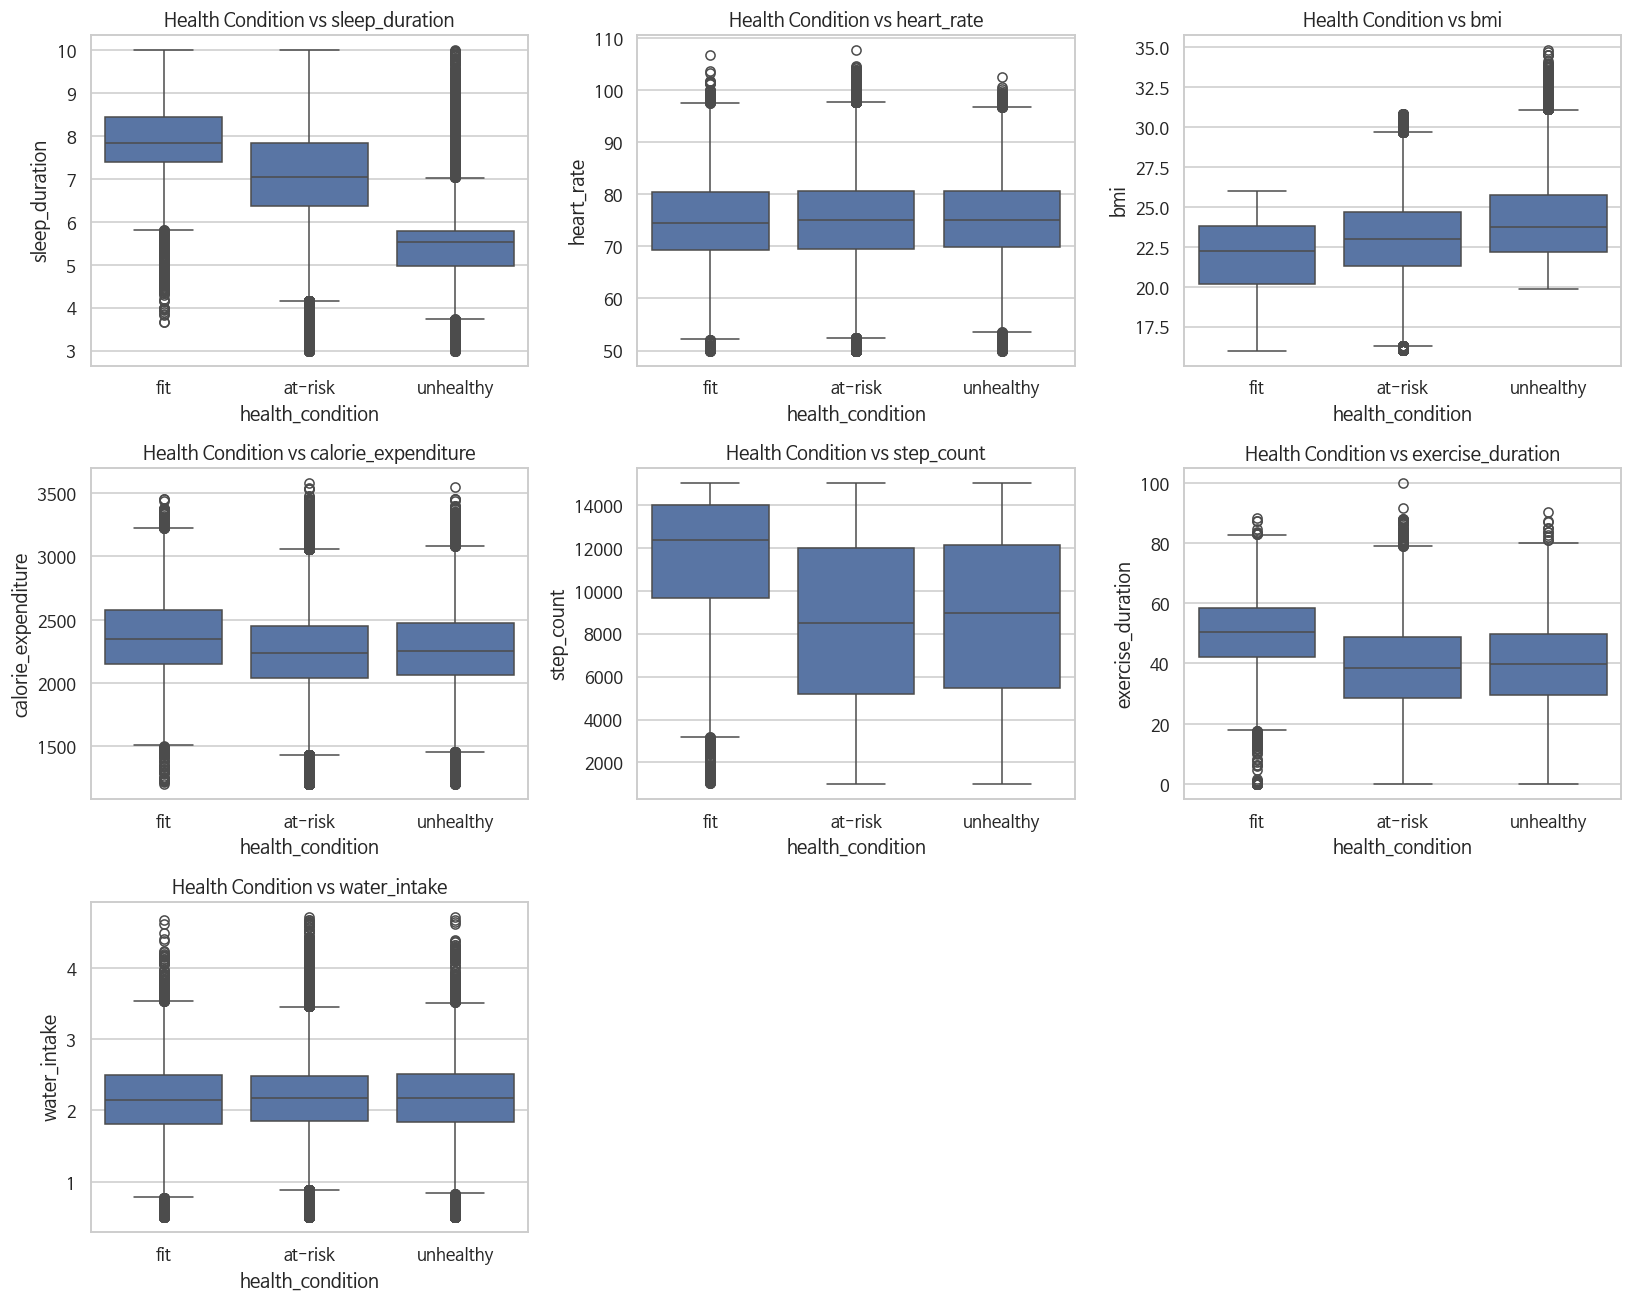

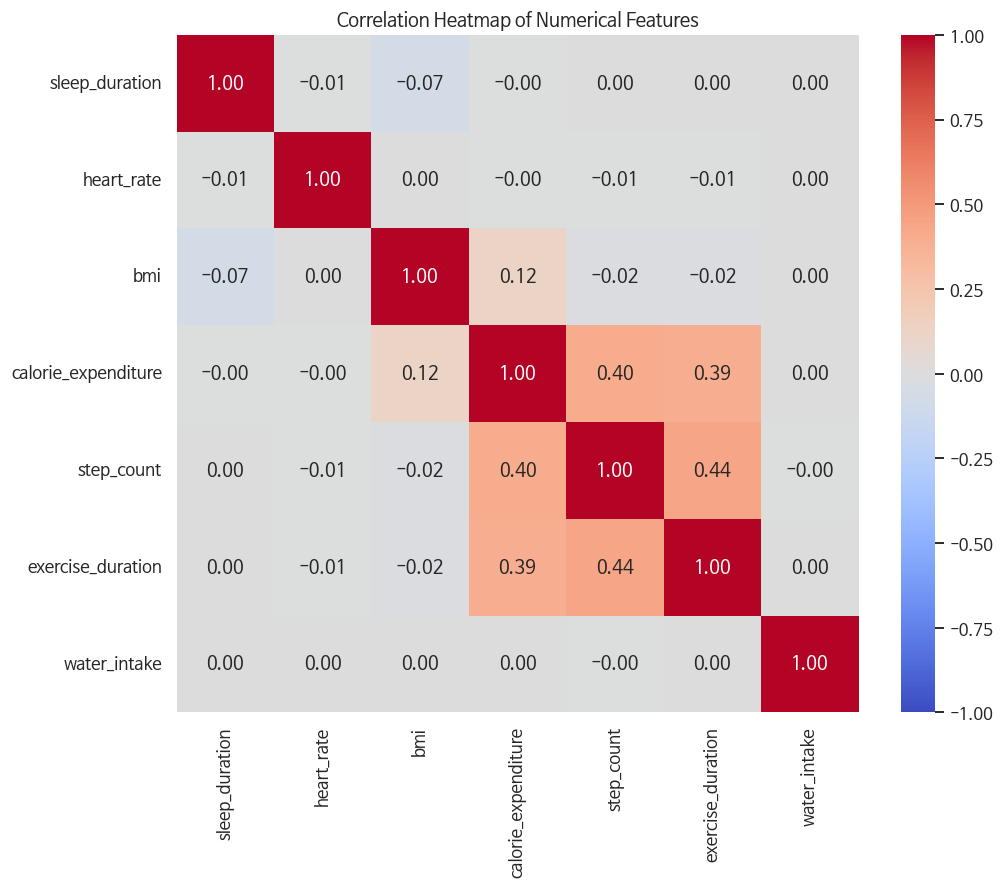

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 데이터 로드 (경로는 실제 환경에 맞게 수정)
train = pd.read_csv(DATA_PATH + 'train.csv')

# 1. 수치형 변수들과 타깃(health_condition)의 관계 시각화 (박스 플롯)
# 시각화할 수치형 변수 리스트
num_cols = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']

# 그래프 크기 설정 (여러 그래프를 한 번에 그리기 위함)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

# 각 수치형 변수에 대해 박스 플롯 그리기
for i, col in enumerate(num_cols):
    sns.boxplot(x='health_condition', y=col, data=train, ax=axes[i], order=['fit', 'at-risk', 'unhealthy'])
    axes[i].set_title(f'Health Condition vs {col}')

# 남는 그래프 공간 숨기기
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# 2. 수치형 변수들 간의 상관관계 히트맵 (Heatmap)
plt.figure(figsize=(10, 8))
# 수치형 데이터만 선택하여 상관계수 계산
corr_matrix = train[num_cols].corr()

# 히트맵 그리기 (annot=True는 숫자를 표시, cmap은 색상 테마)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


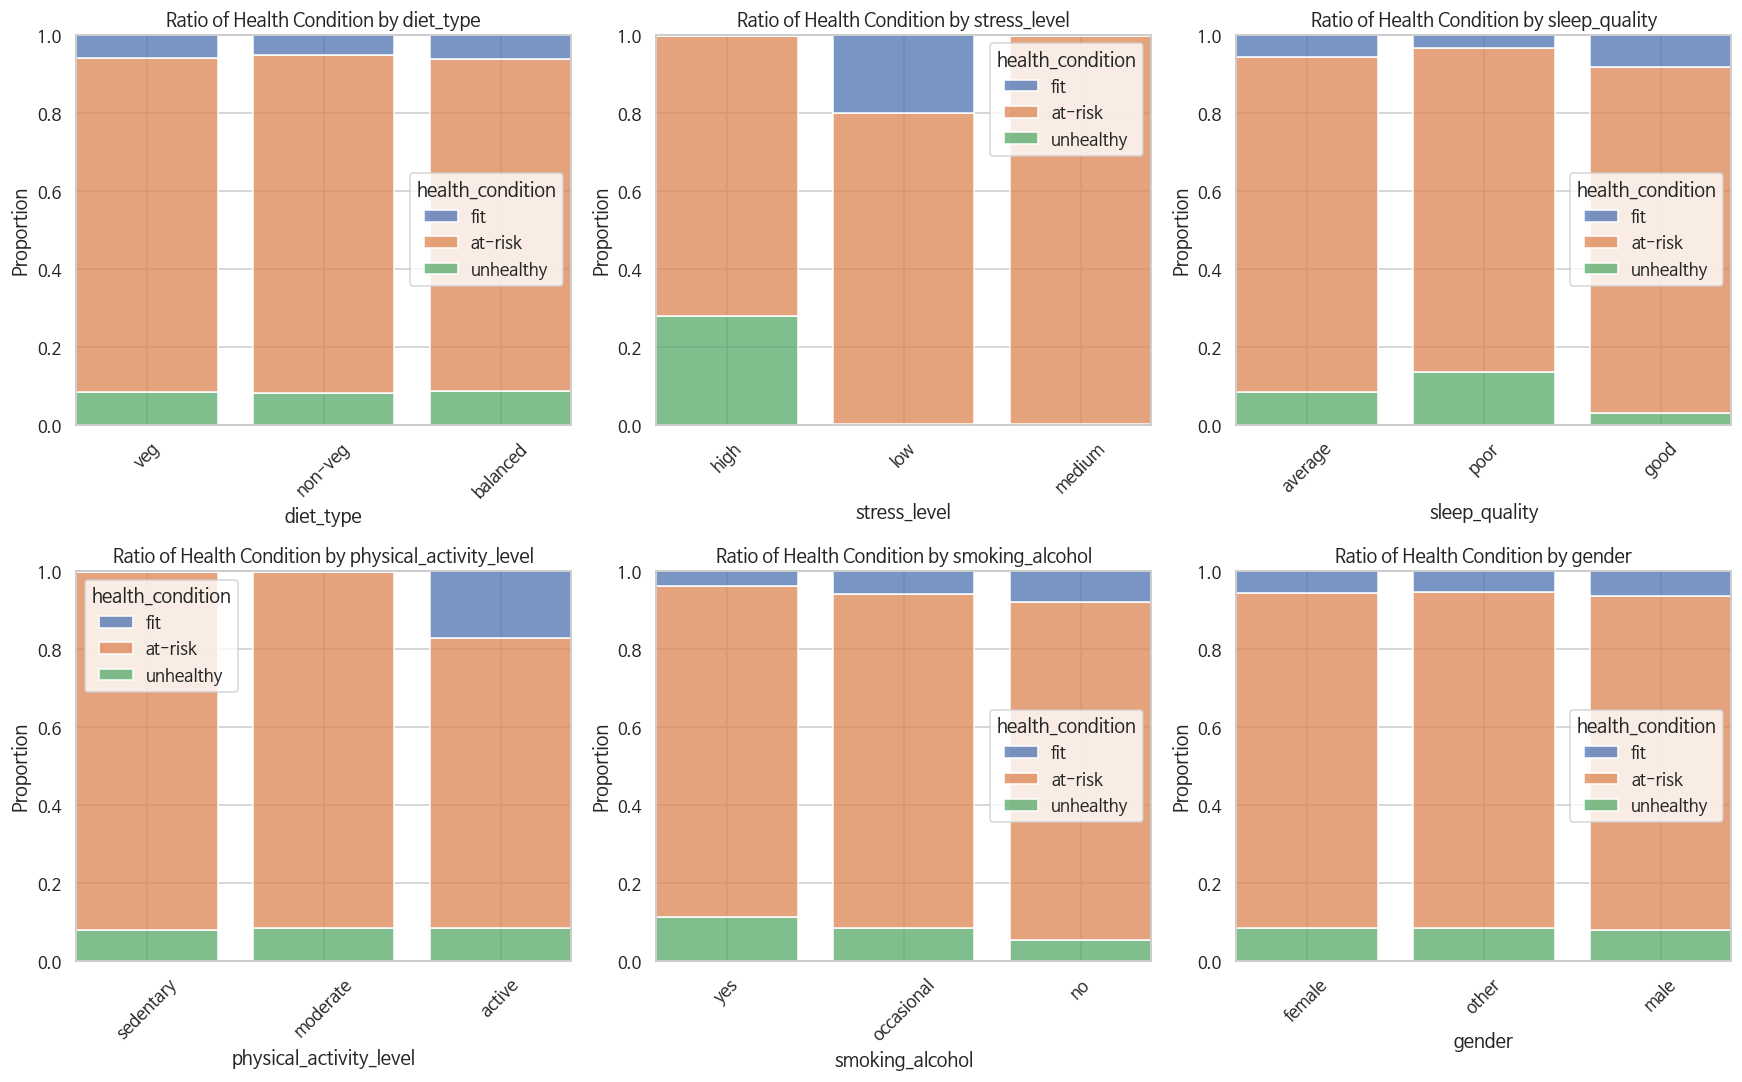

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 범주형(문자형) 컬럼 리스트
cat_cols = [
    'diet_type', 'stress_level', 'sleep_quality',
    'physical_activity_level', 'smoking_alcohol', 'gender'
]

# 2x3 형태의 그래프 틀 생성
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

# 각 범주형 변수마다 100% 누적 막대그래프 그리기
for i, col in enumerate(cat_cols):
    sns.histplot(
        data=train,
        x=col,
        hue='health_condition',
        multiple="fill",   # 100% 비율로 꽉 채워서 그려주는 옵션
        shrink=.8,         # 막대 두께 살짝 얇게
        ax=axes[i],
        hue_order=['fit', 'at-risk', 'unhealthy']
    )
    axes[i].set_title(f'Ratio of Health Condition by {col}')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=45) # X축 글자가 겹치지 않게 45도 기울임

plt.tight_layout()
plt.show()

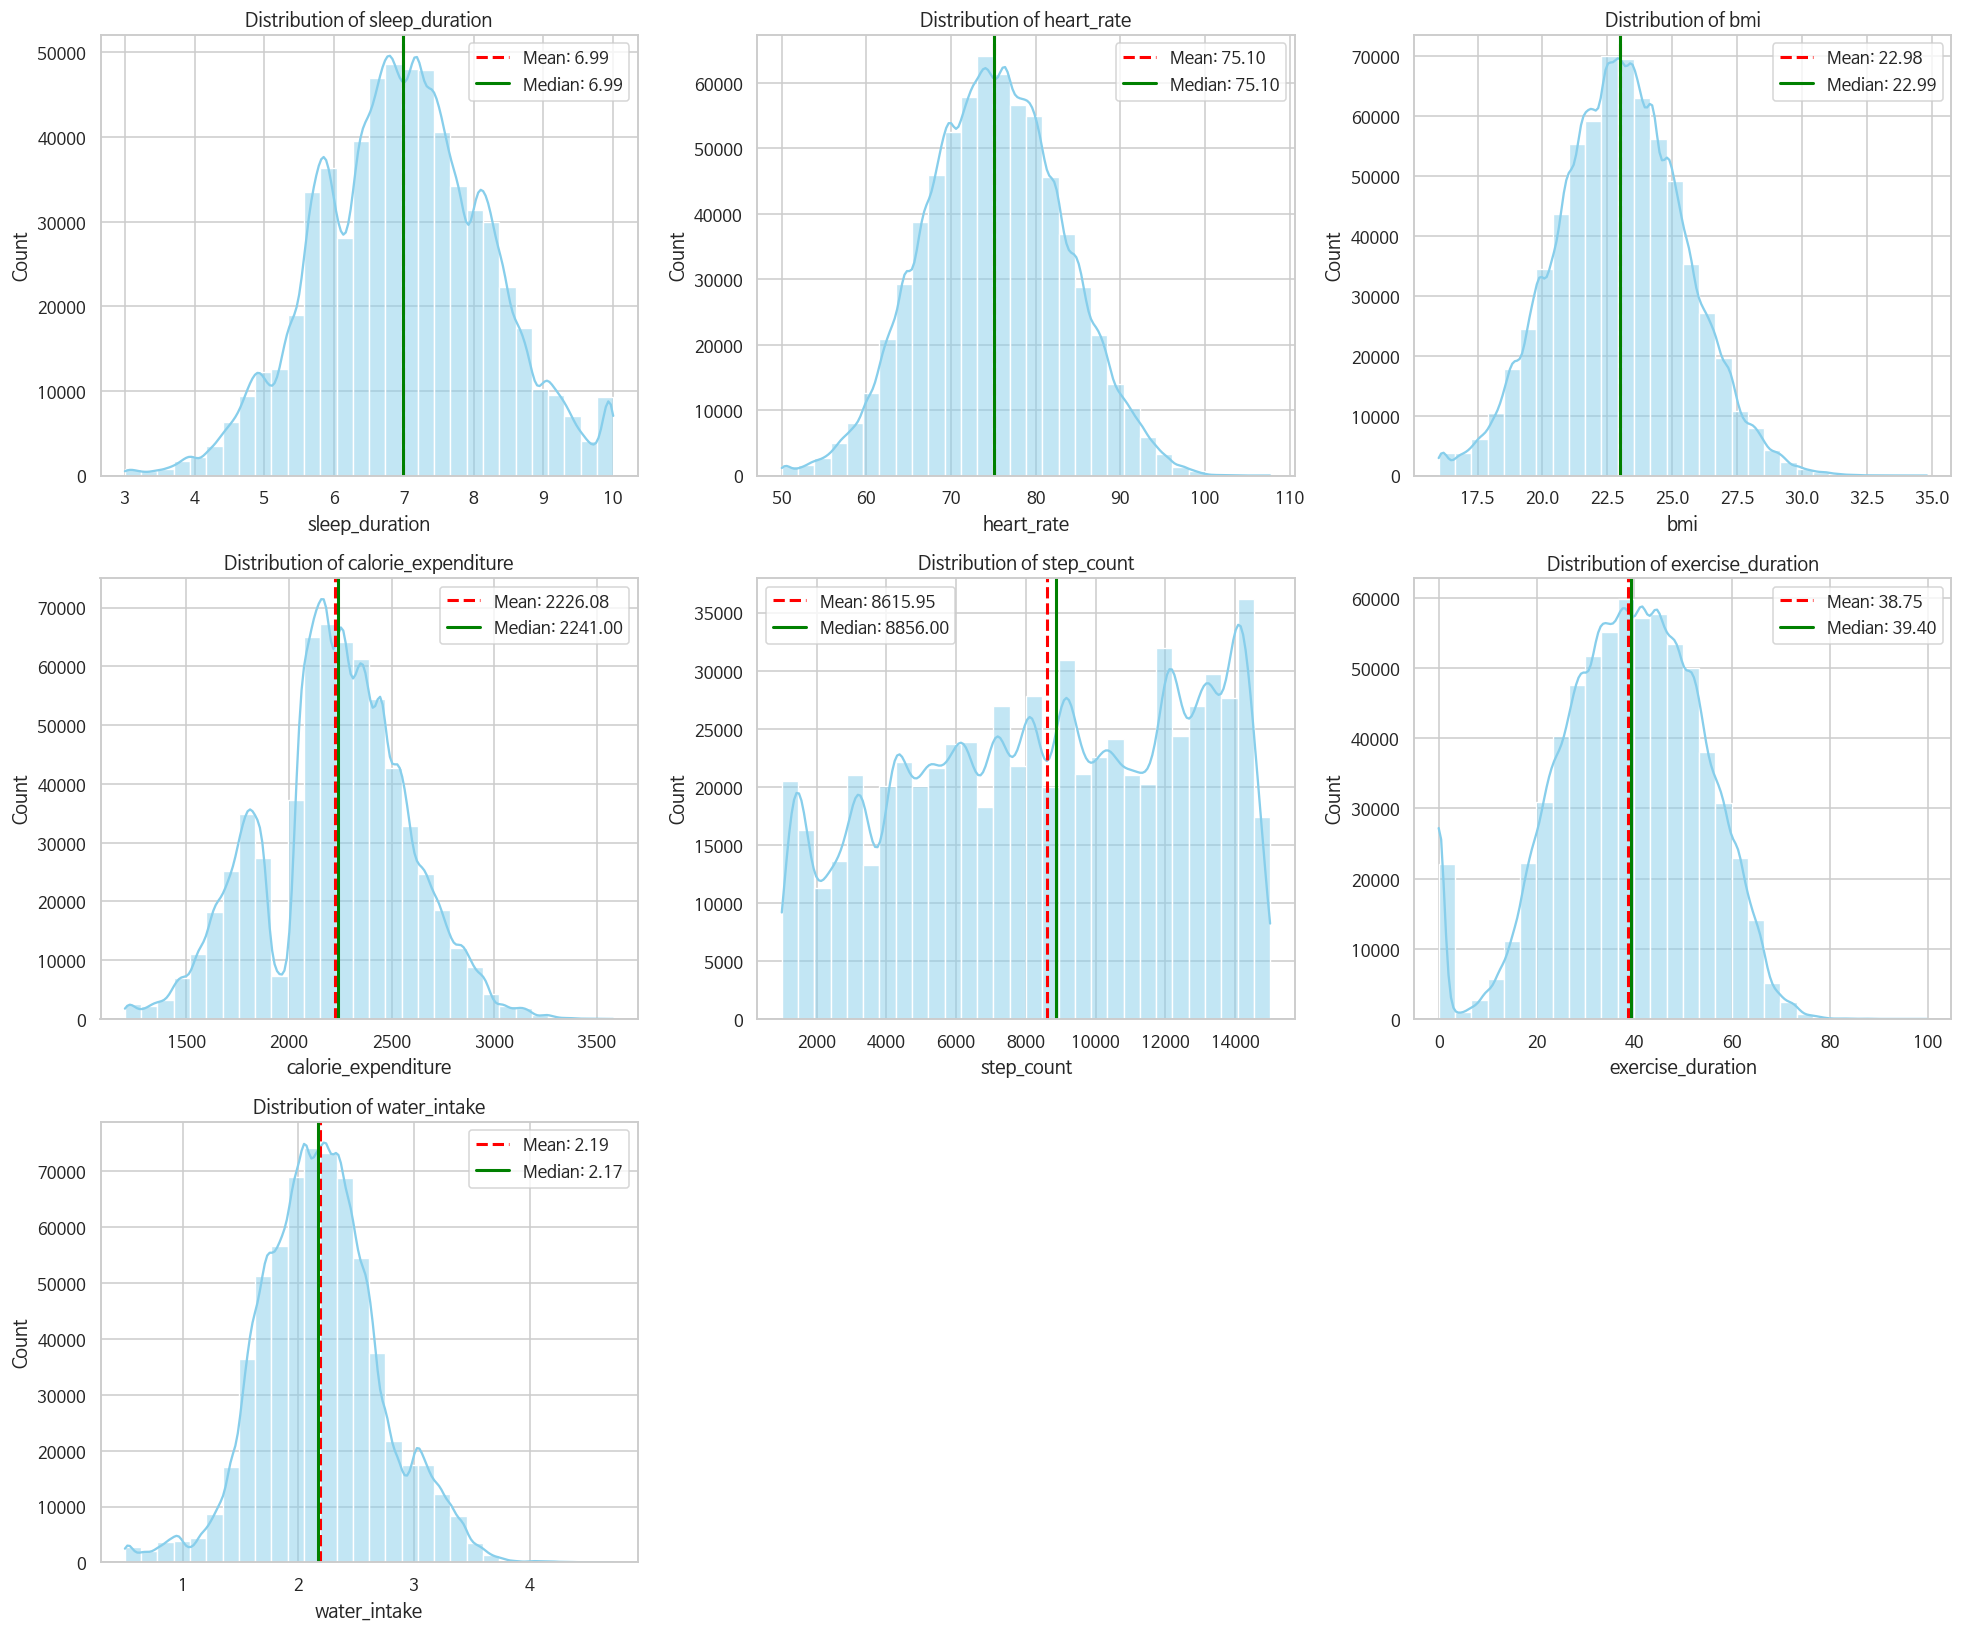

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 로드
train = pd.read_csv(DATA_PATH + 'train.csv')

# 결측치가 있는 수치형 컬럼 리스트
num_missing_cols = [
    'sleep_duration', 'heart_rate', 'bmi',
    'calorie_expenditure', 'step_count',
    'exercise_duration', 'water_intake'
]

# 3x3 형태의 그래프 틀 생성
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(num_missing_cols):
    # 결측치를 제외한 순수 데이터만 추출
    data = train[col].dropna()

    # 평균과 중앙값 계산
    mean_val = data.mean()
    median_val = data.median()

    # 히스토그램과 밀도 함수(KDE) 그리기
    sns.histplot(data, kde=True, ax=axes[i], color='skyblue', bins=30)

    # 평균선 (빨간색 점선)과 중앙값선 (초록색 실선) 추가
    axes[i].axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='solid', linewidth=2, label=f'Median: {median_val:.2f}')

    axes[i].set_title(f'Distribution of {col}')
    axes[i].legend()

# 남는 빈 그래프 공간 숨기기
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# 1. 컬럼들을 성격에 맞게 분류
num_cols = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
# 순서가 없는 범주형
cat_nominal = ['diet_type', 'smoking_alcohol', 'gender']
# 순서가 있는 범주형
cat_ordinal = ['sleep_quality', 'stress_level', 'physical_activity_level']

# 2. 수치형 데이터 컨베이어 벨트 (방금 결정하신 '중앙값' 적용!)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # 빈칸을 중앙값으로 채우기
    ('scaler', StandardScaler())                   # 데이터 크기 단위 맞추기(표준화)
])

# 3. 범주형 데이터 컨베이어 벨트 (일단 뼈대만 잡아둡니다)
nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

# 4. 모든 컨베이어 벨트를 하나로 합치기 (ColumnTransformer)
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('nom', nominal_pipeline, cat_nominal),
    ('ord', ordinal_pipeline, cat_ordinal)
])

print("전처리 파이프라인 조립 완료!")

전처리 파이프라인 조립 완료!


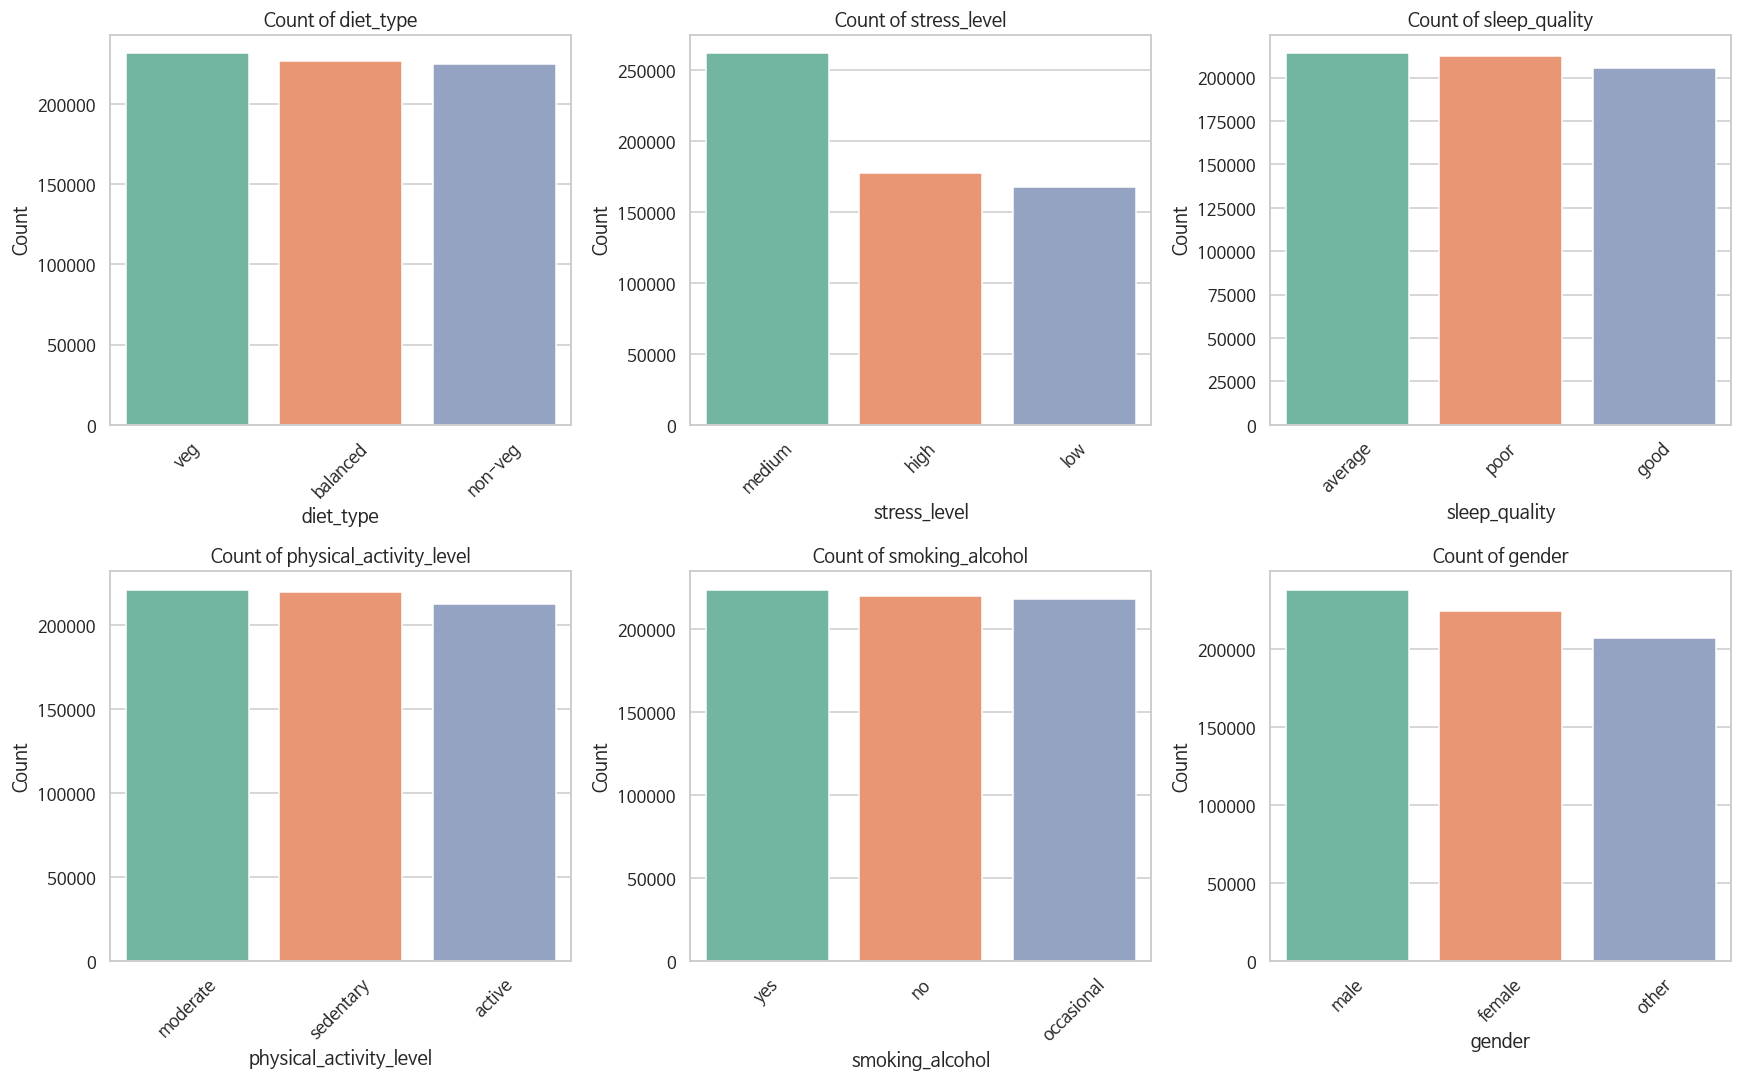

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 로드 train = pd.read_csv('train.csv')

# 결측치가 있는 문자형 컬럼 리스트
cat_missing_cols = [
    'diet_type', 'stress_level', 'sleep_quality',
    'physical_activity_level', 'smoking_alcohol', 'gender'
]

# 2x3 형태의 그래프 틀 생성
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_missing_cols):
    # 항목별 개수를 세어주는 Countplot
    # order 옵션을 통해 가장 개수가 많은 것부터 내림차순으로 정렬
    sns.countplot(
        data=train,
        x=col,
        ax=axes[i],
        order=train[col].value_counts().index,
        palette='Set2'
    )
    axes[i].set_title(f'Count of {col}')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45) # 글자 겹침 방지

plt.tight_layout()
plt.show()

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# 1. 컬럼 분류
num_cols = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
cat_nominal = ['diet_type', 'smoking_alcohol', 'gender']
cat_ordinal = ['sleep_quality', 'stress_level', 'physical_activity_level']

# 2. 수치형 데이터 파이프라인 (결측치: 중앙값 -> 표준화)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 3. 범주형 데이터 파이프라인 (결측치: 'Unknown'으로 채우기!)
# 3-1. 순서가 없는 명목형 데이터 (원-핫 인코딩 적용)
nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# 3-2. 순서가 있는 순서형 데이터 (오디널 인코딩 적용)
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OrdinalEncoder())
])

# 4. 전체 전처리 공정 하나로 합치기
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('nom', nominal_pipeline, cat_nominal),
    ('ord', ordinal_pipeline, cat_ordinal)
])

print("✅ 전처리 파이프라인 조립 완료! (결측치 'Unknown' 처리 적용)")

✅ 전처리 파이프라인 조립 완료! (결측치 'Unknown' 처리 적용)


In [28]:
import pandas as pd
import numpy as np
import time
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 🌟 총 6개의 모델 라이브러리 호출
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

print("준비 작업 시작: 데이터 로드 및 전처리 파이프라인 구성 중...")

# 1. 데이터 로드 및 분리
train = pd.read_csv(DATA_PATH + 'train.csv')
X = train.drop(['id', 'health_condition'], axis=1)
y = train['health_condition']

# 2. 정답지(y)를 숫자로 변환
le = LabelEncoder()
y_numeric = le.fit_transform(y)

# 3. 전처리 공장 (Preprocessor) 세팅
num_cols = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
cat_nominal = ['diet_type', 'smoking_alcohol', 'gender']
cat_ordinal = ['sleep_quality', 'stress_level', 'physical_activity_level']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OrdinalEncoder())
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('nom', nominal_pipeline, cat_nominal),
    ('ord', ordinal_pipeline, cat_ordinal)
])

# 4. 출전할 6명의 선수(모델) 엔트리 구성
models = {
    '1. Random Forest': RandomForestClassifier(n_estimators=50, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1),
    '2. Extra Trees': ExtraTreesClassifier(n_estimators=50, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1),
    '3. HistGradientBoosting': HistGradientBoostingClassifier(class_weight='balanced', random_state=42),
    '4. LightGBM': LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbosity=-1),
    '5. CatBoost': CatBoostClassifier(auto_class_weights='Balanced', random_state=42, verbose=0, thread_count=-1),
    '6. XGBoost': XGBClassifier(random_state=42, n_jobs=-1)
}

# 5. 모의고사(교차검증) 환경 세팅
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

print("\n=======================================================")
print("🏁 총 6개 모델 모의고사(5-Fold) 벤치마크 시작!")
print("=======================================================\n")

# 6. 자동화 평가 루프
for name, model in models.items():
    print(f"▶ [{name}] 학습 및 평가 중...")

    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])

    start_time = time.time()

    # 평가 진행
    scores = cross_val_score(pipeline, X, y_numeric, cv=skf, scoring='balanced_accuracy')

    end_time = time.time()
    elapsed_time = end_time - start_time
    mean_score = scores.mean()

    print(f"   ✓ 완료! | 소요 시간: {elapsed_time:.1f}초 | 균형 정확도: {mean_score:.4f}\n")

    results.append({
        'Model Name': name,
        'Balanced Accuracy': round(mean_score, 4),
        'Time (Seconds)': round(elapsed_time, 1)
    })

# 7. 최종 결과표 요약 및 출력
print("=======================================================")
print("🏆 6대 모델 비교 결과 요약표 (점수 높은 순 정렬)")
print("=======================================================")

results_df = pd.DataFrame(results).sort_values(by='Balanced Accuracy', ascending=False).reset_index(drop=True)
print(results_df.to_string())
print("\n🎉 모든 과정이 완료되었습니다!")

준비 작업 시작: 데이터 로드 및 전처리 파이프라인 구성 중...

🏁 총 6개 모델 모의고사(5-Fold) 벤치마크 시작!

▶ [1. Random Forest] 학습 및 평가 중...
   ✓ 완료! | 소요 시간: 192.2초 | 균형 정확도: 0.9413

▶ [2. Extra Trees] 학습 및 평가 중...
   ✓ 완료! | 소요 시간: 133.3초 | 균형 정확도: 0.8971

▶ [3. HistGradientBoosting] 학습 및 평가 중...
   ✓ 완료! | 소요 시간: 101.1초 | 균형 정확도: 0.9490

▶ [4. LightGBM] 학습 및 평가 중...
   ✓ 완료! | 소요 시간: 64.7초 | 균형 정확도: 0.9495

▶ [5. CatBoost] 학습 및 평가 중...
   ✓ 완료! | 소요 시간: 928.6초 | 균형 정확도: 0.9491

▶ [6. XGBoost] 학습 및 평가 중...
   ✓ 완료! | 소요 시간: 73.4초 | 균형 정확도: 0.8792

🏆 6대 모델 비교 결과 요약표 (점수 높은 순 정렬)
                Model Name  Balanced Accuracy  Time (Seconds)
0              4. LightGBM             0.9495            64.7
1              5. CatBoost             0.9491           928.6
2  3. HistGradientBoosting             0.9490           101.1
3         1. Random Forest             0.9413           192.2
4           2. Extra Trees             0.8971           133.3
5               6. XGBoost             0.8792            73.4

🎉 모든 과정이 완료되었습

라이트GBM만 다시

1. 데이터 로딩 및 정답지 변환 중...
2. 전처리 파이프라인 조립 중...
3. 학습용/검증용 데이터 분할 및 전처리 적용 중...
4. LightGBM 모델 학습 시작 (조기 종료 적용)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014556 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1821
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 22
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training until validation scores don't improve for 50 rounds
[50]	training's multi_logloss: 0.164204	valid_1's multi_logloss: 0.191749
[100]	training's multi_logloss: 0.145629	valid_1's multi_logloss: 0.184958
[150]	training's multi_logloss: 0.133791	valid_1's multi_logloss: 0.180648
[200]	training's multi_logloss: 0.1248	valid_1's multi_logloss: 0.177023
[250]	training

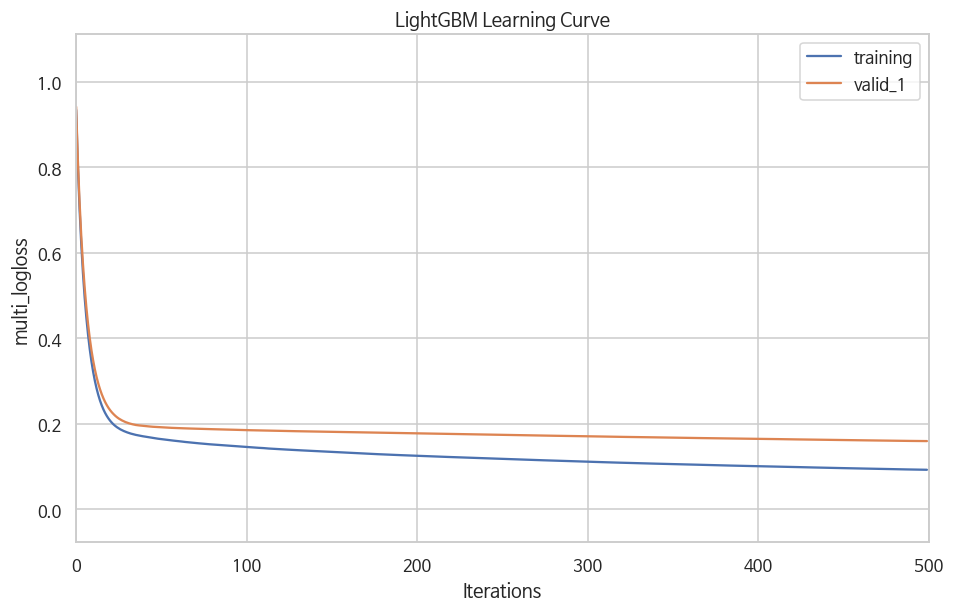


6. 진짜 시험지(test.csv) 예측 및 제출 파일 생성 중...
🎉 모든 복구 및 예측 과정 완료! [submission_lgbm_final.csv] 파일이 성공적으로 저장되었습니다.

[최종 예측 결과 분포]
health_condition
at-risk      240637
unhealthy     33495
fit           21621
Name: count, dtype: int64


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
import lightgbm as lgb
from lightgbm import LGBMClassifier

DATA_PATH = '/content/drive/MyDrive/kaggle_student_heath/'

print("1. 데이터 로딩 및 정답지 변환 중...")
train = pd.read_csv(DATA_PATH + 'train.csv')
test = pd.read_csv(DATA_PATH + 'test.csv')

# 학습용 데이터 분리
X = train.drop(['id', 'health_condition'], axis=1)
y = train['health_condition']

# 테스트용 데이터 분리
X_test = test.drop(['id'], axis=1)
test_ids = test['id']

# 정답지를 숫자(0, 1, 2)로 변환
le = LabelEncoder()
y_numeric = le.fit_transform(y)

print("2. 전처리 파이프라인 조립 중...")
num_cols = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
cat_nominal = ['diet_type', 'smoking_alcohol', 'gender']
cat_ordinal = ['sleep_quality', 'stress_level', 'physical_activity_level']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OrdinalEncoder())
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('nom', nominal_pipeline, cat_nominal),
    ('ord', ordinal_pipeline, cat_ordinal)
])

print("3. 학습용/검증용 데이터 분할 및 전처리 적용 중...")
# 학습 곡선을 그리기 위해 8:2로 쪼갭니다.
X_train, X_val, y_train, y_val = train_test_split(
    X, y_numeric, test_size=0.2, random_state=42, stratify=y_numeric
)

# 데이터 전처리 (시간이 약간 걸립니다)
X_train_trans = preprocessor.fit_transform(X_train)
X_val_trans = preprocessor.transform(X_val)
X_test_trans = preprocessor.transform(X_test) # 테스트 데이터도 미리 전처리!

print("4. LightGBM 모델 학습 시작 (조기 종료 적용)...")
model_lgbm = LGBMClassifier(
    n_estimators=500,        # 나무를 넉넉하게 500개 준비
    class_weight='balanced', # ★핵심★ 클래스 불균형 해결
    random_state=42,
    n_jobs=-1
)

# 조기 종료(Early Stopping)를 적용하여 최적의 타이밍에 학습을 멈춥니다.
model_lgbm.fit(
    X_train_trans, y_train,
    eval_set=[(X_train_trans, y_train), (X_val_trans, y_val)],
    eval_metric='multi_logloss',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(50)]
)

print("\n5. 학습 곡선(과적합 방지) 그래프 출력:")
lgb.plot_metric(model_lgbm, metric='multi_logloss', figsize=(10, 6))
plt.title('LightGBM Learning Curve')
plt.show()

print("\n6. 진짜 시험지(test.csv) 예측 및 제출 파일 생성 중...")
# 멈춘 시점의 최적 모델로 최종 예측
test_pred_numeric = model_lgbm.predict(X_test_trans)
test_pred_labels = le.inverse_transform(test_pred_numeric) # 다시 글자로 복원

# 제출용 데이터프레임 생성
submission = pd.DataFrame({
    'id': test_ids,
    'health_condition': test_pred_labels
})

# CSV 저장
submission_filename = 'submission_lgbm_final.csv'
submission.to_csv(submission_filename, index=False)

print(f"🎉 모든 복구 및 예측 과정 완료! [{submission_filename}] 파일이 성공적으로 저장되었습니다.")
print("\n[최종 예측 결과 분포]")
print(submission['health_condition'].value_counts())

1. 데이터 로딩 및 정답지 변환 중...
2. ★ 파생 변수(Feature Engineering) 생성 중...
3. 전처리 파이프라인 조립 중 (새로운 변수 포함)...
4. 학습용/검증용 분할 및 전처리 적용 중...
5. LightGBM 모델 학습 시작 (조기 종료 적용)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019694 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2334
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 25
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training until validation scores don't improve for 50 rounds
[50]	training's multi_logloss: 0.163741	valid_1's multi_logloss: 0.191618
[100]	training's multi_logloss: 0.14463	valid_1's multi_logloss: 0.184703
[150]	training's multi_logloss: 0.13249	valid_1's multi_logloss: 0.180441
[200]	training's multi_logloss: 0.123376	

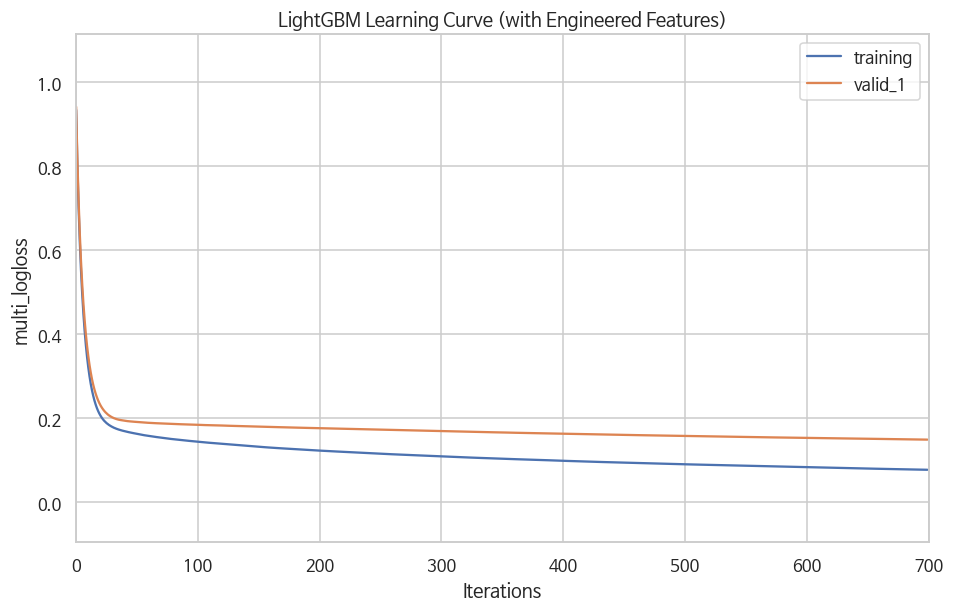


7. 최종 예측 및 제출 파일 생성 중...
🎉 모든 과정 완료! [submission_lgbm_engineered.csv] 파일이 만들어졌습니다.


In [21]:
# 0. 메모리 초기화 (이전 변수 충돌 방지)
try:
    del df
    print("메모리 초기화 완료.")
except NameError:
    pass

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
import lightgbm as lgb
from lightgbm import LGBMClassifier

DATA_PATH = '/content/drive/MyDrive/kaggle_student_heath/'

print("1. 데이터 로딩 및 정답지 변환 중...")
train = pd.read_csv(DATA_PATH + 'train.csv')
test = pd.read_csv(DATA_PATH + 'test.csv')

X = train.drop(['id', 'health_condition'], axis=1)
y = train['health_condition']
X_test = test.drop(['id'], axis=1)
test_ids = test['id']

# 정답지 숫자로 변환 (0, 1, 2)
le = LabelEncoder()
y_numeric = le.fit_transform(y)

print("2. ★ 파생 변수(Feature Engineering) 생성 중...")
def create_features(df_input):
    df_new = df_input.copy()
    # 새로운 변수 3가지 생성
    df_new['exercise_intensity'] = df_new['calorie_expenditure'] / (df_new['exercise_duration'] + 1)
    df_new['activity_per_sleep'] = df_new['step_count'] / (df_new['sleep_duration'] * 1000 + 1)
    df_new['is_obese'] = (df_new['bmi'] >= 25.0).astype(int)
    return df_new

# 반드시 쪼개기(split) 전에 X와 X_test에 새로운 변수를 만들어 덮어씌웁니다! (에러 해결 핵심)
X = create_features(X)
X_test = create_features(X_test)

print("3. 전처리 파이프라인 조립 중 (새로운 변수 포함)...")
# 새로 만든 변수 3개를 num_cols에 완벽히 추가했습니다.
num_cols = [
    'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
    'step_count', 'exercise_duration', 'water_intake',
    'exercise_intensity', 'activity_per_sleep', 'is_obese'
]
cat_nominal = ['diet_type', 'smoking_alcohol', 'gender']
cat_ordinal = ['sleep_quality', 'stress_level', 'physical_activity_level']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OrdinalEncoder())
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('nom', nominal_pipeline, cat_nominal),
    ('ord', ordinal_pipeline, cat_ordinal)
])

print("4. 학습용/검증용 분할 및 전처리 적용 중...")
# 8:2로 데이터 쪼개기
X_train, X_val, y_train, y_val = train_test_split(
    X, y_numeric, test_size=0.2, random_state=42, stratify=y_numeric
)

# 전처리 적용 (이제 컬럼 개수가 딱 맞아서 에러가 안 납니다!)
X_train_trans = preprocessor.fit_transform(X_train)
X_val_trans = preprocessor.transform(X_val)
X_test_trans = preprocessor.transform(X_test)

print("5. LightGBM 모델 학습 시작 (조기 종료 적용)...")
model_lgbm = LGBMClassifier(
    n_estimators=700,        # 파생 변수가 생겼으니 나무를 700개로 조금 더 늘려줍니다.
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_lgbm.fit(
    X_train_trans, y_train,
    eval_set=[(X_train_trans, y_train), (X_val_trans, y_val)],
    eval_metric='multi_logloss',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(50)]
)

print("\n6. 학습 곡선 시각화:")
lgb.plot_metric(model_lgbm, metric='multi_logloss', figsize=(10, 6))
plt.title('LightGBM Learning Curve (with Engineered Features)')
plt.show()

print("\n7. 최종 예측 및 제출 파일 생성 중...")
test_pred_numeric = model_lgbm.predict(X_test_trans)
test_pred_labels = le.inverse_transform(test_pred_numeric)

submission = pd.DataFrame({
    'id': test_ids,
    'health_condition': test_pred_labels
})

submission_filename = 'submission_lgbm_engineered.csv'
submission.to_csv(submission_filename, index=False)

print(f"🎉 모든 과정 완료! [{submission_filename}] 파일이 만들어졌습니다.")

In [23]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 13.6 MB/s eta 0:00:00


In [25]:
# !pip install optuna (설치가 안 되어 있다면 실행)
import optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.metrics import balanced_accuracy_score
import lightgbm as lgb
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore') # 성가신 경고 메시지 숨기기

# ==========================================
# 1. 이전 단계에서 꼬인 메모리 초기화
# ==========================================
try:
    del df, X_engineered, X_test_engineered # 파생변수 관련된 것도 싹 지웁니다.
    print("메모리 초기화 완료")
except NameError:
    pass

# ==========================================
# 2. 데이터 로딩 및 기본 전처리 (파생변수 없음)
# ==========================================
DATA_PATH = '/content/drive/MyDrive/kaggle_student_heath/'

train = pd.read_csv(DATA_PATH + 'train.csv')
test = pd.read_csv(DATA_PATH + 'test.csv')

X = train.drop(['id', 'health_condition'], axis=1)
y = train['health_condition']
X_test = test.drop(['id'], axis=1)
test_ids = test['id']

le = LabelEncoder()
y_numeric = le.fit_transform(y)

# 전처리 파이프라인 (원래대로 복구)
num_cols = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
cat_nominal = ['diet_type', 'smoking_alcohol', 'gender']
cat_ordinal = ['sleep_quality', 'stress_level', 'physical_activity_level']

num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
nominal_pipeline = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')), ('encoder', OneHotEncoder(handle_unknown='ignore'))])
ordinal_pipeline = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')), ('encoder', OrdinalEncoder())])

preprocessor = ColumnTransformer([('num', num_pipeline, num_cols), ('nom', nominal_pipeline, cat_nominal), ('ord', ordinal_pipeline, cat_ordinal)])

# 학습/검증 데이터 분할 및 전처리 (Optuna 튜닝용)
X_train, X_val, y_train, y_val = train_test_split(X, y_numeric, test_size=0.2, random_state=42, stratify=y_numeric)
X_train_trans = preprocessor.fit_transform(X_train)
X_val_trans = preprocessor.transform(X_val)
X_test_trans = preprocessor.transform(X_test)

# ==========================================
# 3. Optuna: LightGBM 최적 파라미터 탐색 설계
# ==========================================
print("\n🔍 Optuna 튜닝 시작! (AI가 최적의 조합을 찾는 중...)")

def objective(trial):
    # AI가 테스트해 볼 하이퍼파라미터의 범위(공간)를 지정해 줍니다.
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000), # 나무 개수
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.1), # 학습 속도 (작을수록 꼼꼼함)
        'num_leaves': trial.suggest_int('num_leaves', 31, 128), # 나뭇잎(조건 분기) 개수
        'max_depth': trial.suggest_int('max_depth', 5, 15), # 나무의 최대 깊이
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100), # 한 잎사귀에 최소 몇 개의 데이터가 있어야 하는지
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.5, 1.0), # 컬럼 무작위 선택 비율
        'class_weight': 'balanced', # 절대 빼먹으면 안 되는 필수 옵션!
        'random_state': 42,
        'n_jobs': -1
    }

    # 위에서 고른 조합으로 모델 생성
    model = LGBMClassifier(**param)

    # 훈련!
    model.fit(
        X_train_trans, y_train,
        eval_set=[(X_val_trans, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)] # 30번 안 오르면 스톱
    )

    # 검증 데이터로 예측하고 균형 정확도(Balanced Accuracy) 계산
    preds = model.predict(X_val_trans)
    score = balanced_accuracy_score(y_val, preds)

    return score # 이 점수가 가장 높아지도록 AI가 훈련을 반복합니다.

# ==========================================
# 4. Optuna 실행 및 결과 확인
# ==========================================
# study: 점수를 최대화(maximize)하는 방향으로 탐색 시작!
study = optuna.create_study(direction='maximize')

# 15번의 테스트를 진행합니다. (데이터가 커서 15번도 꽤 걸립니다. 시간 여유가 있다면 30~50으로 늘려도 됩니다)
study.optimize(objective, n_trials=15)

print('\n🏆 최고 점수(Balanced Accuracy):', study.best_value)
print('✨ 최적의 파라미터 조합:', study.best_params)

# ==========================================
# 5. 최적 파라미터로 최종 학습 및 예측
# ==========================================
print("\n🚀 찾은 최적의 조합으로 최종 학습 시작!")
best_params = study.best_params
best_params['class_weight'] = 'balanced'
best_params['random_state'] = 42

final_model = LGBMClassifier(**best_params)
final_model.fit(
    X_train_trans, y_train,
    eval_set=[(X_val_trans, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# 예측 및 제출 파일 저장
final_preds_numeric = final_model.predict(X_test_trans)
final_preds_labels = le.inverse_transform(final_preds_numeric)

submission = pd.DataFrame({'id': test_ids, 'health_condition': final_preds_labels})
submission_filename = 'submission_lgbm_optuna.csv'
submission.to_csv(submission_filename, index=False)

print(f"\n🎉 튜닝 완료! [{submission_filename}] 파일이 저장되었습니다.")

[I 2026-07-14 02:50:24,456] A new study created in memory with name: no-name-12bc2f89-985f-4868-bee7-48193f04bfa5



🔍 Optuna 튜닝 시작! (AI가 최적의 조합을 찾는 중...)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014586 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1821
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 22
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


[I 2026-07-14 02:52:02,136] Trial 0 finished with value: 0.949579899302652 and parameters: {'n_estimators': 746, 'learning_rate': 0.034176253323896524, 'num_leaves': 38, 'max_depth': 8, 'min_child_samples': 62, 'colsample_bytree': 0.9832256423058682}. Best is trial 0 with value: 0.949579899302652.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.052339 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1821
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 22
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


[I 2026-07-14 02:53:37,404] Trial 1 finished with value: 0.9498423511383908 and parameters: {'n_estimators': 626, 'learning_rate': 0.02685195969798846, 'num_leaves': 63, 'max_depth': 15, 'min_child_samples': 68, 'colsample_bytree': 0.6416629299699337}. Best is trial 1 with value: 0.9498423511383908.


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.052395 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1821
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 22
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


[I 2026-07-14 03:11:55,211] Trial 13 finished with value: 0.9493560267470499 and parameters: {'n_estimators': 449, 'learning_rate': 0.05065165445309356, 'num_leaves': 84, 'max_depth': 15, 'min_child_samples': 54, 'colsample_bytree': 0.6249258807000763}. Best is trial 8 with value: 0.9498916044790482.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014484 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1821
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 22
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

[I 2026-07-14 03:13:01,290] Trial 14 finished with value: 0.9495747363061363 and parameters: {'n_estimators': 435, 'learning_rate': 0.01692986322074468, 'num_leaves': 46, 'max_depth': 5, 'min_child_samples': 82, 'colsample_bytree': 0.8505526827856251}. Best is trial 8 with value: 0.9498916044790482.



🏆 최고 점수(Balanced Accuracy): 0.9498916044790482
✨ 최적의 파라미터 조합: {'n_estimators': 380, 'learning_rate': 0.04083541528069318, 'num_leaves': 92, 'max_depth': 5, 'min_child_samples': 89, 'colsample_bytree': 0.9695329106115744}

🚀 찾은 최적의 조합으로 최종 학습 시작!
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015441 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1821
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 22
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training unt

# 추가 시각화 자료 추출

1. 모델이 생각하는 가장 중요한 변수들 (Feature Importance)


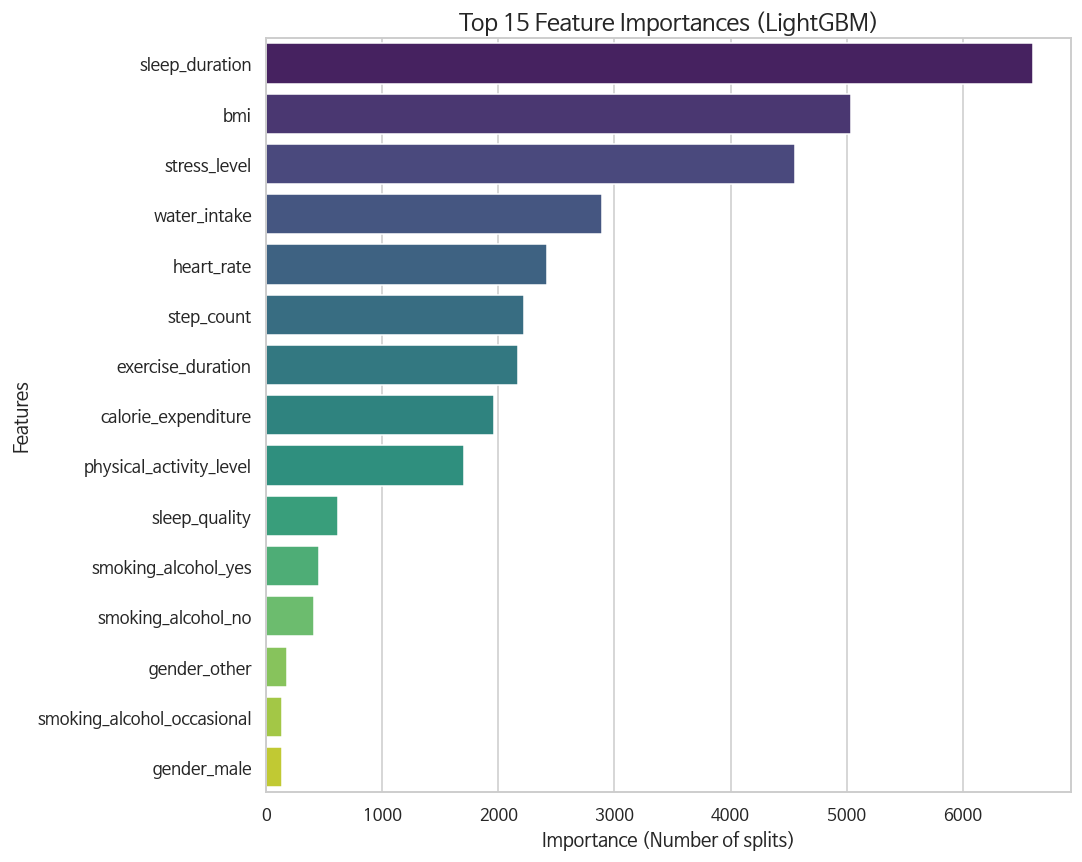


2. 모델의 예측 상세 결과 (Confusion Matrix)


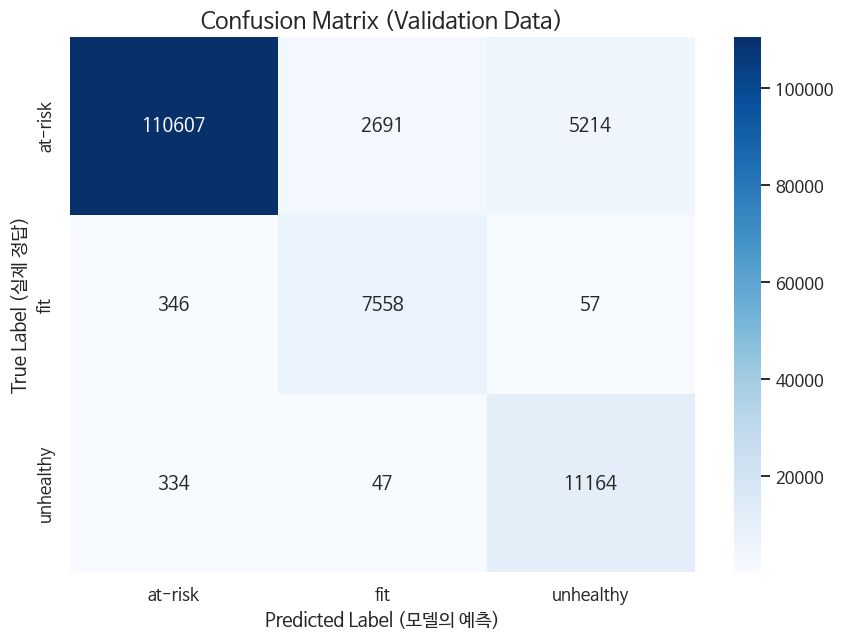

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# (주의: 앞선 Optuna 코드에서 생성된 final_model, X_val_trans, y_val, preprocessor가 메모리에 있어야 합니다.)

# ---------------------------------------------------------
# 1. 변수 중요도 (Feature Importance) 그래프
# ---------------------------------------------------------
print("1. 모델이 생각하는 가장 중요한 변수들 (Feature Importance)")

# 파이프라인(ColumnTransformer)을 통과하고 난 뒤의 컬럼 이름들을 가져오는 작업
# 숫자형은 그대로, 범주형은 One-hot 등에 의해 이름이 바뀌므로 이를 추출합니다.
feature_names = []
feature_names.extend(num_cols)
# 명목형(OneHot)의 변환된 이름 가져오기
cat_nominal_features = preprocessor.named_transformers_['nom'].named_steps['encoder'].get_feature_names_out(cat_nominal)
feature_names.extend(cat_nominal_features)
# 순서형(Ordinal)은 이름이 안 바뀌므로 그대로 사용
feature_names.extend(cat_ordinal)

# 모델의 중요도 점수 추출
importances = final_model.feature_importances_

# 보기 좋게 데이터프레임으로 묶어서 정렬
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 상위 15개 변수만 뽑아서 막대그래프 그리기
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances (LightGBM)', fontsize=15)
plt.xlabel('Importance (Number of splits)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. 혼동 행렬 (Confusion Matrix) 그래프
# ---------------------------------------------------------
print("\n2. 모델의 예측 상세 결과 (Confusion Matrix)")

# 검증 데이터(Validation)로 예측 수행
val_preds = final_model.predict(X_val_trans)

# 혼동 행렬 계산
cm = confusion_matrix(y_val, val_preds)
class_labels = le.classes_ # ['at-risk', 'fit', 'unhealthy']

# 히트맵으로 깔끔하게 그리기
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix (Validation Data)', fontsize=15)
plt.xlabel('Predicted Label (모델의 예측)', fontsize=12)
plt.ylabel('True Label (실제 정답)', fontsize=12)
plt.tight_layout()
plt.show()

# 앙상블 (튜닝+기본+기본)

In [29]:
import pandas as pd
import numpy as np

print("1. 앙상블을 위한 3대장 모델 세팅 중...")

# ① 튜닝된 대장: LightGBM (방금 Optuna로 찾은 최고 설정값 그대로 적용)
# (주의: 앞선 Optuna 코드의 best_params가 메모리에 있어야 합니다)
lgbm_best = LGBMClassifier(**best_params)

# ② 든든한 국밥: CatBoost (순정 상태, 튜닝 X)
from catboost import CatBoostClassifier
cat_default = CatBoostClassifier(auto_class_weights='Balanced', random_state=42, verbose=0, thread_count=-1)

# ③ 사이킷런의 숨겨진 무기: HistGradientBoosting (순정 상태, 튜닝 X)
from sklearn.ensemble import HistGradientBoostingClassifier
hgb_default = HistGradientBoostingClassifier(class_weight='balanced', random_state=42)


print("\n2. 각 모델별 학습 및 시험지 예측(확률 추출) 시작...")
print("▶ [1/3] LightGBM 진행 중...")
lgbm_best.fit(
    X_train_trans, y_train,
    eval_set=[(X_val_trans, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False)]
)
# predict()가 아니라 predict_proba()를 써서 0, 1, 2일 확률을 각각 가져옵니다!
lgbm_proba = lgbm_best.predict_proba(X_test_trans)

print("▶ [2/3] CatBoost 진행 중... (가장 오래 걸립니다. 약 10~15분 예상 ☕️)")
cat_default.fit(
    X_train_trans, y_train,
    eval_set=[(X_val_trans, y_val)],
    early_stopping_rounds=30, verbose=False
)
cat_proba = cat_default.predict_proba(X_test_trans)

print("▶ [3/3] HistGradientBoosting 진행 중...")
hgb_default.fit(X_train_trans, y_train) # 자체 조기종료 로직이 내장되어 있어 그냥 fit만 합니다.
hgb_proba = hgb_default.predict_proba(X_test_trans)


print("\n3. 예측 확률 통합 (Soft Voting) 계산 중...")
# 세 모델의 확률을 공평하게 더해서 3으로 나눕니다 (평균)
final_proba = (lgbm_proba + cat_proba + hgb_proba) / 3

# 평균 확률 중 가장 높은 숫자의 위치(0, 1, 2)를 정답으로 쾅 찍습니다.
final_pred_numeric = np.argmax(final_proba, axis=1)


print("4. 캐글 제출용 최종 답안지 생성 중...")
# 0, 1, 2 숫자를 다시 'at-risk', 'fit', 'unhealthy' 글자로 복원
final_pred_labels = le.inverse_transform(final_pred_numeric)

submission = pd.DataFrame({
    'id': test_ids,
    'health_condition': final_pred_labels
})

submission_filename = 'submission_ensemble_top3.csv'
submission.to_csv(submission_filename, index=False)

print(f"\n🎉 앙상블 완료! [{submission_filename}] 파일이 완벽하게 저장되었습니다.")

1. 앙상블을 위한 3대장 모델 세팅 중...

2. 각 모델별 학습 및 시험지 예측(확률 추출) 시작...
▶ [1/3] LightGBM 진행 중...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019388 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1821
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 22
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

---------------------

# ppt 논의

지금까지 도출된 완벽한 논리 흐름을 바탕으로, 복사해서 바로 PPT 장표에 옮겨 담을 수 있는 텍스트 초안을 작성해 드립니다.면접관과 평가자를 설득하기 위해 '우리가 왜 이런 선택을 했는지'에 대한 철학과 비즈니스적 결단이 돋보이도록 구성했습니다.

### Slide 1: 타이틀
- 대주제: AI 기반 학생 건강 상태 분류 최적화 및 초개인화 케어 서비스 제안
- 부제: 극심한 데이터 불균형 극복 및 경량화 모델 배포 전략을 중심으로
- 발표자: [이름 기입]

### Slide 2: 문제 정의 (Situation & Complication)
- 분석 배경: 불규칙한 생활 습관으로 인한 학생들의 전반적인 건강 악화 우려 및 데이터 수집 진행.
- 데이터 현황: 총 69만 건의 대용량 학생 건강 데이터 확보.
- 치명적 위기(Complication): 전체 데이터의 85%가 '위험군(at-risk)'에 편향되어 있음.
- 위기의 결과: 일반적인 AI 모델 적용 시 다수결의 함정에 빠져, 실제 건강한 학생(fit)이나 이미 건강이 붕괴된 학생(unhealthy)을 제대로 찾아내지 못하는 심각한 오분류 발생.

### Slide 3: 프로젝트 목표 (Question & Answer)
- 핵심 과제(Question): 심각한 데이터 불균형을 극복하고, 실제 서비스에 즉시 탑재할 수 있는 가장 빠르고 정확한 예측 모델은 무엇인가?
- 해결 방안(Answer): 결측치 고유 정보 보존 전처리와 LightGBM 기반의 경량화 AI 파이프라인 구축.
- 최종 목표: 단순한 위험 판별을 넘어, 오프라인 및 모바일 환경에서 작동하는 실시간 건강 트리아지(Triage) 시스템 구현.

### Slide 4: 데이터 전처리 전략 (결측치의 재발견)
- 수치형 데이터: 극단적인 이상치(Outlier)로 인한 모델 왜곡을 방어하기 위해 평균(Mean) 대신 중앙값(Median) 대치 채택.
- 범주형 데이터 (핵심): 5~8만 개에 달하는 결측치를 최빈값으로 무작정 덮어씌우지 않음.
- 인사이트: 빈칸 자체를 'Unknown'이라는 독립적인 범주로 분리하여 모델에 힌트로 제공함으로써 원본 데이터의 분포 왜곡을 원천 차단함.

### Slide 5: 파생 변수 실험과 합성 데이터의 한계
- 가설 설정: '운동 강도(칼로리/시간)' 등 상식적인 인간의 수식을 파생 변수로 추가하면 모델의 성능이 오를 것이다.
- 검증 결과: 파생 변수 추가 후 모델 성능 오히려 하락 (0.9493 ➔ 0.9476).
- 분석 인사이트: 본 데이터셋은 합성 데이터(Synthetic Data)의 특성을 가짐.
- 전략 수정: 인위적인 사칙연산이 알고리즘 고유의 비선형적 패턴 인식을 방해하는 노이즈로 작용함을 증명하고, 원본 데이터 특성을 최대한 살리는 방향으로 선회.

### Slide 6: 6대 머신러닝 모델 벤치마크 (효율성 검증)
모델명,균형 정확도 (Balanced Accuracy),학습 및 추론 소요 시간
+ LightGBM (선택),0.9495,64.7초
+ CatBoost,0.9491,928.6초
+ HistGradientBoosting,0.9490,101.1초
+ Random Forest,0.9413,192.2초
+ Extra Trees,0.8971,133.3초
+ XGBoost,0.8792,73.4초
- 벤치마크 결론: LightGBM과 CatBoost의 성능 격차는 0.0004로 무의미한 수준이나, 속도 면에서 LightGBM이 무려 14배 이상 빠름을 확인.

### Slide 7: Optuna 하이퍼파라미터 튜닝 및 과적합 방지
- [이미지 삽입]: LightGBM Learning Curve (학습 곡선 그래프)
- 튜닝 전략: Optuna AI 자동 탐색을 통해 LightGBM의 한계 성능(Global Maxima) 도출 시도.
- 안전 장치: 조기 종료(Early Stopping) 기법을 적용하여 훈련 데이터만 외워버리는 과적합(Overfitting) 현상을 완벽하게 차단.
- 결과 도출: 가장 효율적인 트리 깊이와 잎사귀 개수의 최적 조합을 찾아내어 0.9495 성능 고정.

### Slide 8: 앙상블(Ensemble) 시도 및 비즈니스적 결단
- 실험 내용: 성능 극대화를 위해 3대장 모델(튜닝된 LightGBM + 기본 CatBoost + 기본 HGB)의 예측 확률을 합치는 Soft Voting 앙상블 진행.
- 실험 결과: 앙상블 모델과 LightGBM 단일 모델의 최종 점수가 소수점까지 동일함.
- 인사이트: 단일 LightGBM이 이미 해당 데이터셋에서 도달할 수 있는 최대 성능치에 도달했음을 교차 검증함.
- 비즈니스 결단: 무의미한 서버 연산량 증가와 유지보수 비용 발생을 막기 위해 앙상블을 폐기하고 단일 LightGBM 확정.
### Slide 9: 최종 예측 성능 분석
- [이미지 삽입]: LightGBM 단일 모델의 혼동 행렬 (Confusion Matrix)
- 클래스 가중치 효과: class_weight='balanced' 적용의 성공적 결과.
- 결과 해석: 극소수 클래스인 '건강함(fit)'과 '위험(unhealthy)' 클래스에 대한 모델의 분류 방어선이 무너지지 않고 정확하게 작동하고 있음을 증명.

### Slide 10: Action Plan 1 - 예측 모델의 경량화 배포 전략
- 플랫폼 통합: 확정된 가벼운 LightGBM 모델을 오프라인 환경인 윈도우 기반 건강 측정 키오스크에 직접 이식.
- 모바일 확장: Unity 기반 인터페이스나 Android Studio를 활용한 교내 모바일 도우미 앱에 모델을 연동.
- 기대 효과: 클라우드 서버 통신 없이 기기 자체(On-device)에서 즉각적인 연산이 가능하여, 학생들에게 끊김 없는 실시간 헬스케어 안내 제공.

### Slide 11: Action Plan 2 - Feature 기반 초개인화(Hyper-Personalization)
- [이미지 삽입]: LightGBM 변수 중요도 (Feature Importance 바 차트)
- 주요 요인: AI 판별 결과, 학생 건강을 위협하는 3대 요인은 [수면 퀄리티], [스트레스 지수], [심박수]로 도출됨. (※ 실제 그래프 결과에 맞춰 단어 수정)
- AI 트리아지(Triage) 서비스: 앱이 백그라운드에서 위험군(at-risk) 도달 확률 80%를 감지하면 선제적 개입.
- 개인화 넛지(Nudge): "수면 패턴이 무너졌습니다. 교내 상담 센터 수면 테라피를 예약하시겠습니까?" 와 같이 변수 중요도 역추적을 통한 맞춤형 솔루션 제공.

### [한계점 및 향후 발전 방향]
- 한계점: 본 프로젝트에서는 실시간 서비스 배포(추론 속도 64초)를 최우선으로 고려하여 단일 LightGBM 모델을 채택함.
- 향후 연구(Future Works): 만약 로컬 기기가 아닌, 컴퓨팅 리소스가 충분한 클라우드 서버 환경으로 아키텍처가 확장된다면 '스태킹(Stacking) 앙상블' 도입을 고려할 수 있음.
- 5개의 서로 다른 베이스 모델의 예측 확률을 새로운 Feature로 삼고, 메타 분류기(Meta-Classifier)를 통해 재추론하는 방식을 적용한다면 0.95 고지를 넘어서는 추가적인 정확도 향상을 기대할 수 있음.

https://docs.google.com/presentation/d/1l4BDY5spwlyIi7IJQzcC6QJ7uDSBTJyq99-6xiIcrdY/edit?usp=sharing

-------------------

# 잉여 코드

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from lightgbm import LGBMClassifier

# 1. 훈련용(Train)과 모의고사용(Validation) 데이터 8:2로 쪼개기
# (여기서 y_numeric은 앞서 만들어둔 0,1,2 숫자로 된 정답지입니다)
X_train, X_val, y_train, y_val = train_test_split(
    X, y_numeric, test_size=0.2, random_state=42, stratify=y_numeric
)

# 2. 전처리 파이프라인 가동 (주의: fit은 무조건 train에만!)
X_train_trans = preprocessor.fit_transform(X_train)
X_val_trans = preprocessor.transform(X_val)

# 3. LightGBM 모델 세팅 (나무를 일부러 500개까지 아주 넉넉하게 줍니다)
model_lgbm = LGBMClassifier(
    n_estimators=500,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 4. 학습 시작 및 평가 기록 (eval_set)
print("LightGBM 학습 및 검증 평가 기록 중...")
model_lgbm.fit(
    X_train_trans, y_train,
    eval_set=[(X_train_trans, y_train), (X_val_trans, y_val)], # 훈련문제와 모의고사 문제 동시 투입
    eval_metric='multi_logloss', # 다중분류의 오차 측정 기준
    callbacks=[lgb.early_stopping(stopping_rounds=50)] # 50번 연속 모의고사 점수가 안 오르면 강제 종료!
)

# 5. 과적합(학습 곡선) 그래프 그리기
print("\n과적합 시각화 그래프 출력:")
lgb.plot_metric(model_lgbm, metric='multi_logloss', figsize=(10, 6))
plt.title('LightGBM Learning Curve (Train vs Validation Loss)')
plt.show()

NameError: name 'X' is not defined

In [15]:
import pandas as pd

DATA_PATH = '/content/drive/MyDrive/kaggle_student_heath/'

print("1. 진짜 시험지(test.csv) 불러오는 중...")
test = pd.read_csv(DATA_PATH + 'test.csv')
test_ids = test['id'] # 제출할 때 학생 id가 필요하므로 따로 빼둡니다.

# 테스트 데이터에서 id 컬럼 제거 (모델은 이 정보가 필요 없음)
X_test = test.drop(['id'], axis=1)

print("2. 테스트 데이터 전처리 중... (주의: transform만 사용!)")
# ★ 아주 중요: 테스트 데이터는 fit_transform이 아니라 반드시 transform을 써야 합니다!
X_test_trans = preprocessor.transform(X_test)

print("3. LightGBM 모델로 최종 예측 수행 중...")
# 앞선 셀(Early Stopping 코드)에서 학습을 마친 model_lgbm을 그대로 사용합니다.
test_pred_numeric = model_lgbm.predict(X_test_trans)

print("4. 예측된 숫자(0,1,2)를 원래 글자로 복원 중...")
# 부스팅 모델 때문에 0, 1, 2로 바꿨던 정답을 다시 'fit', 'at-risk', 'unhealthy'로 되돌립니다.
test_pred_labels = le.inverse_transform(test_pred_numeric)

print("5. 캐글 제출용 OMR 답안지(CSV) 생성 중...")
# sample_submission.csv 양식에 맞게 DataFrame 생성
submission = pd.DataFrame({
    'id': test_ids,
    'health_condition': test_pred_labels
})

# CSV 파일로 저장
submission_filename = 'submission_lgbm_final.csv'
submission.to_csv(submission_filename, index=False)

print(f"\n🎉 모든 과정 완료! [{submission_filename}] 파일이 성공적으로 저장되었습니다.")
print("\n[최종 예측 결과 분포]")
print(submission['health_condition'].value_counts())

1. 진짜 시험지(test.csv) 불러오는 중...
2. 테스트 데이터 전처리 중... (주의: transform만 사용!)


NotFittedError: This ColumnTransformer instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.